In [1]:
import pandas as pd
import h5py
import numpy as np
import matplotlib.pyplot as plt
import random

# Path ke file hasil "Grand Merger" Anda
HDF5_PATH = '/Volumes/Extreme SSD/stream_stead/data_stead/merge.hdf5'
CSV_PATH = '/Volumes/Extreme SSD/stream_stead/data_stead/merge.csv'

# 1. Baca Buku Indeks (Metadata)
df = pd.read_csv(CSV_PATH)

# Pisahkan daftar nama trace berdasarkan kategorinya
gempa_list = df[df['trace_category'] == 'earthquake_local']['trace_name'].tolist()
noise_list = df[df['trace_category'] == 'noise']['trace_name'].tolist()

# Pilih 1 gempa dan 1 noise secara acak
trace_gempa = random.choice(gempa_list) if gempa_list else None
trace_noise = random.choice(noise_list) if noise_list else None

# Fungsi untuk mem-plot 3 komponen ala STEAD
def plot_waveform(data_array, title):
    # Sumbu X (Waktu) -> 6000 sampel dibagi 100 Hz = 60 detik
    t = np.linspace(0, 60, 6000)
    
    fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
    fig.suptitle(title, fontsize=14, fontweight='bold')
    
    komponen = ['Timur (E)', 'Utara (N)', 'Vertikal (Z)']
    warna = ['#1f77b4', '#ff7f0e', '#2ca02c']
    
    for i in range(3):
        axes[i].plot(t, data_array[:, i], color=warna[i], linewidth=0.8)
        axes[i].set_ylabel(komponen[i], fontsize=10)
        axes[i].grid(True, linestyle='--', alpha=0.6)
        
    axes[2].set_xlabel("Waktu (Detik)", fontsize=12)
    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.show()

# 2. Buka Brankas HDF5 dan Plot Datanya
with h5py.File(HDF5_PATH, 'r') as hf:
    
    if trace_gempa and trace_gempa in hf:
        print(f"Menggambar Gelombang Gempa: {trace_gempa}")
        data_gempa = hf[trace_gempa][:]
        plot_waveform(data_gempa, f"Kategori: Gempa Bumi Lokal (LE)\nTrace: {trace_gempa}")
        
    if trace_noise and trace_noise in hf:
        print(f"Menggambar Gelombang Bising: {trace_noise}")
        data_noise = hf[trace_noise][:]
        plot_waveform(data_noise, f"Kategori: Seismik Noise (NO)\nTrace: {trace_noise}")

/var/folders/lt/2mkl6ry53ll9fdk2br6skfgw0000gn/T/ipykernel_7468/1342688949.py:12: DtypeWarning: Columns (7,11,13,14,24,25,26,30,31) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(CSV_PATH)


In [2]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
import random

HDF5_PATH = '/Volumes/Local Disk/Code_Git/S3_code/seismic/waveform_indonesia_usgs_bmkg_katalog/STEAD_Indonesia_2004_2010_Final.hdf5'

def plot_random_samples(hdf5_path):
    with h5py.File(hdf5_path, 'r') as hf:
        # Pisahkan keys berdasarkan kategori
        le_keys = [k for k in hf.keys() if hf[k].attrs['category'] == 'earthquake_local']
        no_keys = [k for k in hf.keys() if hf[k].attrs['category'] == 'noise']
        
        # Ambil sampel acak
        le_sample = random.choice(le_keys)
        no_sample = random.choice(no_keys)
        
        data_le = hf[le_sample][:] # Matriks (6000, 3)
        data_no = hf[no_sample][:]
        
        # Plotting
        fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True)
        components = ['Timur (E)', 'Utara (N)', 'Vertikal (Z)']
        
        # Plot Gempa
        for i in range(3):
            axes[0, i].plot(data_le[:, i], color='red', linewidth=0.5)
            axes[0, i].set_title(f"LE: {le_sample} | {components[i]}")
            axes[0, i].grid(True, alpha=0.3)
            
        # Plot Noise
        for i in range(3):
            axes[1, i].plot(data_no[:, i], color='blue', linewidth=0.5)
            axes[1, i].set_title(f"NO: {no_sample} | {components[i]}")
            axes[1, i].grid(True, alpha=0.3)
            
        plt.tight_layout()
        plt.show()

plot_random_samples(HDF5_PATH)

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/Volumes/Local Disk/Code_Git/S3_code/seismic/waveform_indonesia_usgs_bmkg_katalog/STEAD_Indonesia_2004_2010_Final.hdf5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [ ]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
import random

HDF5_PATH = '/Volumes/Local Disk/Code_Git/S3_code/seismic/waveform_indonesia_usgs_bmkg_katalog/output_waveform_indonesia_0109/STEAD_Indonesia_Final_2004_2010.hdf5'

def plot_random_samples(hdf5_path):
    with h5py.File(hdf5_path, 'r') as hf:
        # Pisahkan keys berdasarkan kategori (menggunakan atribut metadata)
        le_keys = [k for k in hf.keys() if hf[k].attrs.get('trace_category') == 'earthquake_local']
        no_keys = [k for k in hf.keys() if hf[k].attrs.get('trace_category') == 'noise']
        
        # Ambil sampel acak
        le_sample = random.choice(le_keys)
        no_sample = random.choice(no_keys)
        
        data_le = hf[le_sample][:] # Matriks (6000, 3)
        data_no = hf[no_sample][:]
        
        # Plotting
        fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True)
        components = ['Timur (E)', 'Utara (N)', 'Vertikal (Z)']
        
        # Plot Gempa
        for i in range(3):
            axes[0, i].plot(data_le[:, i], color='red', linewidth=0.5)
            axes[0, i].set_title(f"LE: {le_sample} | {components[i]}")
            axes[0, i].grid(True, alpha=0.3)
            
        # Plot Noise
        for i in range(3):
            axes[1, i].plot(data_no[:, i], color='blue', linewidth=0.5)
            axes[1, i].set_title(f"NO: {no_sample} | {components[i]}")
            axes[1, i].grid(True, alpha=0.3)
            
        plt.tight_layout()
        plt.show()

plot_random_samples(HDF5_PATH)

Membaca data dan memetakan statistik...
Data LE terkumpul: 27849, Data NO terkumpul: 27849


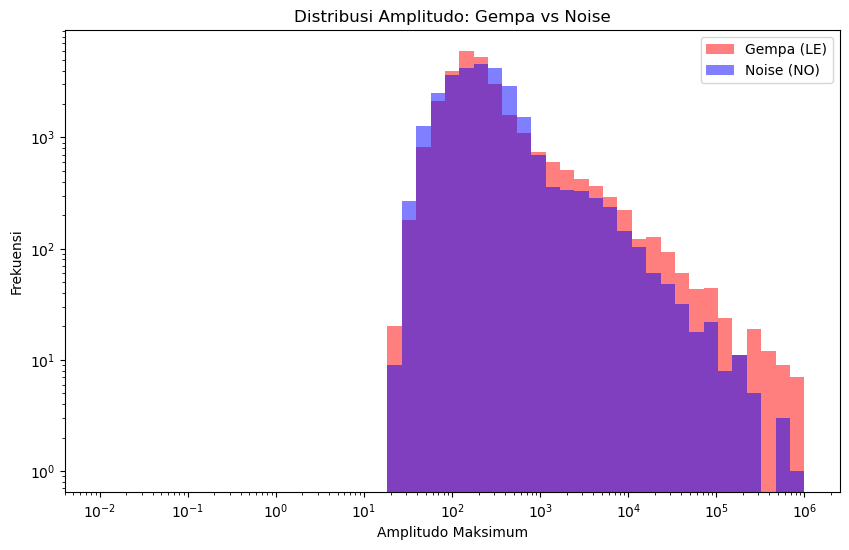

In [3]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

HDF5_PATH = '/Volumes/Local Disk/Code_Git/S3_code/seismic/waveform_indonesia_usgs_bmkg_katalog/output_waveform_indonesia_0109/STEAD_Indonesia_Final_2004_2010.hdf5'

def visualize_dataset_stats(h5_path):
    le_amps = []
    no_amps = []
    
    print("Membaca data dan memetakan statistik...")
    with h5py.File(h5_path, 'r') as hf:
        for key in hf.keys():
            dset = hf[key]
            # MENGGUNAKAN ATRIBUT YANG BENAR: 'trace_category'
            cat = dset.attrs.get('trace_category', 'unknown')
            data = dset[:]
            max_amp = np.max(np.abs(data))
            
            if cat == 'earthquake_local':
                le_amps.append(max_amp)
            elif cat == 'noise':
                no_amps.append(max_amp)
                
    print(f"Data LE terkumpul: {len(le_amps)}, Data NO terkumpul: {len(no_amps)}")
    
    if len(le_amps) == 0 or len(no_amps) == 0:
        print("Data masih tidak terdeteksi. Periksa ejaan kategori di atribut.")
        return

    # Plotting
    plt.figure(figsize=(10, 6))
    bins = np.logspace(-2, 6, 50)
    plt.hist(le_amps, bins=bins, color='red', alpha=0.5, label='Gempa (LE)', log=True)
    plt.hist(no_amps, bins=bins, color='blue', alpha=0.5, label='Noise (NO)', log=True)
    plt.xscale('log')
    plt.xlabel('Amplitudo Maksimum')
    plt.ylabel('Frekuensi')
    plt.title('Distribusi Amplitudo: Gempa vs Noise')
    plt.legend()
    plt.show()

visualize_dataset_stats(HDF5_PATH)

In [ ]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

HDF5_PATH = '/Volumes/Local Disk/Code_Git/S3_code/seismic/waveform_indonesia_usgs_bmkg_katalog/output_waveform_indonesia_0109/STEAD_Indonesia_Final_2004_2010.hdf5'

def analyze_significance(h5_path):
    le_amps = []
    no_amps = []
    
    print("Menganalisis statistik kelas...")
    with h5py.File(h5_path, 'r') as hf:
        for key in hf.keys():
            dset = hf[key]
            # Menggunakan atribut yang terverifikasi: 'trace_category'
            cat = dset.attrs.get('trace_category', 'unknown')
            data = dset[:]
            max_amp = np.max(np.abs(data))
            
            if cat == 'earthquake_local':
                le_amps.append(max_amp)
            elif cat == 'noise':
                no_amps.append(max_amp)

    # Menghitung statistik dasar
    le_arr = np.array(le_amps)
    no_arr = np.array(no_amps)
    
    print(f"\n--- Analisis Signifikansi ---")
    print(f"Rerata Amplitudo LE: {np.mean(le_arr):.2f}")
    print(f"Rerata Amplitudo NO: {np.mean(no_arr):.2f}")
    print(f"Perbandingan rasio (LE/NO): {np.mean(le_arr)/np.mean(no_arr):.2f}x")
    
    # Visualisasi perbandingan distribusi
    plt.figure(figsize=(10, 5))
    bins = np.logspace(0, 5, 50)
    plt.hist(le_arr, bins=bins, color='red', alpha=0.5, label='Gempa (LE)', log=True)
    plt.hist(no_arr, bins=bins, color='blue', alpha=0.5, label='Noise (NO)', log=True)
    plt.xscale('log')
    plt.xlabel('Amplitudo Maksimum (Log Scale)')
    plt.ylabel('Frekuensi (Log Scale)')
    plt.title('Distribusi Signifikansi: Gempa vs Noise')
    plt.legend()
    plt.show()

analyze_significance(HDF5_PATH)

In [ ]:
# -*- coding: utf-8 -*-
import os
import collections

# ==============================================================================
# 🎛️ TARGET DIREKTORI DATASET LOKAL INDONESIA BAPAK
# ==============================================================================
PATH_TARGET_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/waveform_indonesia_usgs_bmkg_katalog/output_waveform_indonesia_0109'

def audit_kompatibilitas_3c_dataset():
    print("="*90)
    print("🔍 STARTING: FORENSIC DATASET AUDIT FOR 3-COMPONENT (3C) COMPATIBILITY")
    print("="*90)
    
    if not os.path.exists(PATH_TARGET_DIR):
        print(f"❌ GALAT: Jalur direktori tidak ditemukan di: {PATH_TARGET_DIR}")
        return

    total_mseed_files = 0
    
    # Dictionary untuk mencatat komponen apa saja yang ada di setiap folder event stasiun
    # Struktur key: (path_folder, prefix_nama_stasiun_event) -> value: set of components ['n', 'e', 'z']
    peta_komponen_stasiun = collections.defaultdict(set)
    
    # Penghitung string akhiran mentah untuk melihat pola penamaan asli file Bapak
    penghitung_akhiran_mentah = collections.Counter()

    print("⏳ Menyisir seluruh subfolder event gempa secara rekursif (os.walk)...")
    for root, dirs, files in os.walk(PATH_TARGET_DIR):
        mseed_in_folder = [f for f in files if f.endswith('.mseed')]
        total_mseed_files += len(mseed_in_folder)
        
        for file_name in mseed_in_folder:
            name_lower = file_name.lower()
            
            # 1. Deteksi komponen spasial secara agnostik
            komponen_ditemukan = None
            if 'z' in name_lower:
                komponen_ditemukan = 'Z'
            elif 'n' in name_lower:
                komponen_ditemukan = 'N'
            elif 'e' in name_lower:
                komponen_ditemukan = 'E'
                
            # 2. Ekstraksi ekstensi/akhiran unik untuk analisis metadata penamaan
            # Contoh: mengambil '_BHZ_LE.mseed' atau '_LE.mseed'
            parts = file_name.split('_')
            if len(parts) >= 2:
                akhiran_key = "_".join(parts[-2:])
                penghitung_akhiran_mentah[akhiran_key] += 1
            else:
                penghitung_akhiran_mentah[file_name] += 1

            # 3. Kelompokkan berdasarkan stasiun unik di dalam subfolder yang sama
            # Kita buat key unik gabungan antara folder root dan base name stasiun (tanpa komponen & tipe)
            # Contoh nama file: II_KAPI_00_BHZ_LE.mseed -> base identifier: II_KAPI_00
            base_identifier = file_name
            for token in ['_bhz', '_bhn', '_bhe', '_hhz', '_hhn', '_hhe', '_z', '_n', '_e', '_le', '_no', '_LE', '_NO']:
                base_identifier = base_identifier.replace(token, '').replace(token.upper(), '')
            
            # Bersihkan sisa ekstensi mseed
            base_identifier = base_identifier.replace('.mseed', '')
            
            if komponen_ditemukan:
                key_stasiun_event = (root, base_identifier)
                peta_komponen_stasiun[key_stasiun_event].add(komponen_ditemukan)

    # 4. Hitung statistik hasil pengelompokan komponen 3C
    stasiun_1c_z_only = 0
    stasiun_3c_lengkap = 0
    stasiun_lainnya = 0
    
    for komponen_set in peta_komponen_stasiun.values():
        if komponen_set == {'Z'}:
            stasiun_1c_z_only += 1
        elif {'N', 'E', 'Z'}.issubset(komponen_set) or komponen_set == {'N', 'E', 'Z'}:
            stasiun_3c_lengkap += 1
        else:
            stasiun_lainnya += 1

    # ==============================================================================
    # 📊 LAPORAN HASIL AUDIT FORENSIK JUPYTER
    # ==============================================================================
    print("\n📊" + "="*36 + " RINGKASAN METADATA DATASET " + "="*36)
    print(f"• Total File MiniSEED (.mseed) Ditemukan : {total_mseed_files} berkas")
    print(f"• Total Folder Event + Stasiun Unik      : {len(peta_komponen_stasiun)} kombinasi")
    print("-" * 90)
    print("📋 SEBARAN STRUKTUR KOMPONEN SEISMIK LOKAL:")
    print(f"  🟢 Paket 1-Komponen (Hanya Z Vertikal Murni) : {stasiun_1c_z_only} paket stasiun")
    print(f"  🔵 Paket 3-Komponen (Lengkap N + E + Z)      : {stasiun_3c_lengkap} paket stasiun")
    print(f"  🟡 Paket Komponen Parsial/Lainnya            : {stasiun_lainnya} paket stasiun")
    print("-" * 90)
    
    print("📋 TOP 5 POLA AKHIRAN NAMA FILE YANG PALING DOMINAN:")
    for akhiran, jumlah in penghitung_akhiran_mentah.most_common(5):
        print(f"  👉 Pattern: *_{akhiran} -> Terdeteksi sebanyak: {jumlah} file")
    print("-" * 90)
    
    # 5. KESIMPULAN OPERASIONAL SEJATI
    print("📢 KESIMPULAN KOMPATIBILITAS DATA:")
    if stasiun_3c_lengkap > 0 and stasiun_3c_lengkap >= (len(peta_komponen_stasiun) * 0.8):
        print("  ✅ DATASET INI MENDUKUNG 3C SEJATI!")
        print("     Mayoritas stasiun memiliki file komponen N, E, dan Z secara lengkap di subfoldernya.")
    elif stasiun_1c_z_only > 0 and stasiun_3c_lengkap == 0:
        print("  ❌ DATASET INI TIDAK MENDUKUNG 3C (MURNI 1C VERTIKAL)!")
        print("     Seluruh berkas di dalam folder Anda murni hanya berisi komponen gelombang vertikal (Z).")
        print("     Jika ingin menjalankan evaluasi 3C sejati, Anda wajib mengunduh file komponen N dan E terlebih dahulu.")
    else:
        print("  ⚠️ DATASET BERSIFAT CAMPURAN (HYBRID)!")
        print(f"     Hanya ada {stasiun_3c_lengkap} stasiun yang lengkap 3C. Sisanya terfragmentasi.")
    print("="*90)

if __name__ == "__main__":
    audit_kompatibilitas_3c_dataset()

In [ ]:
import os
import glob
import random
from obspy import read

# ⚠️ GANTI dengan path BASE_DIR Anda
BASE_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/waveform_buffer/waveform_ready'

search_pattern = os.path.join(BASE_DIR, '*', '*', '*.mseed')
mseed_files = glob.glob(search_pattern)

if not mseed_files:
    print("❌ File tidak ditemukan.")
else:
    sample_file = random.choice(mseed_files)
    print(f"📂 Event ID : {os.path.basename(os.path.dirname(sample_file))}")
    print(f"📄 File     : {os.path.basename(sample_file)}\n")
    
    try:
        st = read(sample_file)
        st = st[:3] # Ambil 3 komponen pertama

        print("📈 Menampilkan Data Mentah (RAW)...")
        st.plot(size=(800, 300), color='grey')
        
        # ==========================================
        # 🛠️ LANGKAH PREPROCESSING WAJIB SEBELUM FILTER
        # ==========================================
        st_filtered = st.copy()
        
        # 1. Demean: Tarik semua grafik agar titik tengahnya tepat di 0
        st_filtered.detrend('demean')
        
        # 2. Linear Detrend: Hilangkan tren miring/menanjak akibat sensor drift
        st_filtered.detrend('linear')
        
        # 3. Tapering: Lembutkan 5% ujung awal dan akhir agar filter tidak "kaget" (ringing)
        st_filtered.taper(max_percentage=0.05, type='cosine')
        
        # 4. Baru lakukan Bandpass Filter
        st_filtered.filter('bandpass', freqmin=1.0, freqmax=5.0, corners=4, zerophase=True)
        
        print("📉 Menampilkan Data Filter (Setelah Detrend & Demean)...")
        st_filtered.plot(size=(800, 300), color='blue')
        
    except Exception as e:
        print(f"⚠️ Gagal memproses: {e}")

In [ ]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt

# ⚠️ GANTI dengan path direktori utama Anda
BASE_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/waveform_buffer/waveform_ready'

print("🔍 Menyisir direktori untuk audit data...")
search_pattern = os.path.join(BASE_DIR, '*', '*', '*.mseed')
mseed_files = glob.glob(search_pattern)

if not mseed_files:
    print("❌ Tidak ada file .mseed yang ditemukan. Cek kembali path BASE_DIR.")
else:
    print(f"✅ Total {len(mseed_files):,} file berhasil dipetakan. Sedang menyusun laporan...\n")
    
    # 1. Ekstraksi Metadata dari Path File
    koleksi_data = []
    for filepath in mseed_files:
        # Memecah path berdasarkan separator OS (/ pada Mac)
        parts = filepath.split(os.sep)
        
        # Berdasarkan struktur direktori: BASE_DIR / Tahun / Event_ID / file.mseed
        tahun = parts[-3]
        event_id = parts[-2]
        nama_file = parts[-1]
        
        koleksi_data.append({
            'Tahun': tahun,
            'Event_ID': event_id,
            'File_Name': nama_file
        })
        
    df_audit = pd.DataFrame(koleksi_data)
    
    # 2. Perhitungan Statistik Dasar
    total_file = len(df_audit)
    total_event_unik = df_audit['Event_ID'].nunique()
    rata_rata_stasiun_per_event = total_file / total_event_unik if total_event_unik > 0 else 0
    
    print("=" * 50)
    print("📊 RINGKASAN DATASET GELOMBANG SEISMIK (2001 - 2024)")
    print("=" * 50)
    print(f"Total File (.mseed)        : {total_file:,} gelombang 3-komponen")
    print(f"Total Kejadian Gempa Unik  : {total_event_unik:,} event")
    print(f"Rata-rata Sensor per Gempa : {rata_rata_stasiun_per_event:.1f} stasiun")
    print("-" * 50)
    
    # 3. Distribusi Data per Tahun
    distribusi_tahun = df_audit.groupby('Tahun')['File_Name'].count().sort_index()
    
    # Tampilkan tabel distribusi
    print("\n📅 Distribusi File per Tahun:")
    print(distribusi_tahun.to_string())
    
    # 4. Visualisasi Grafik Distribusi
    plt.figure(figsize=(14, 6))
    bars = plt.bar(distribusi_tahun.index, distribusi_tahun.values, color='steelblue', edgecolor='black')
    
    # Tambahkan label angka di atas setiap bar
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + (yval*0.02), int(yval), 
                 ha='center', va='bottom', fontsize=9)
                 
    plt.title('Distribusi Rekaman Seismik 3-Komponen (Berdasarkan Tahun)', fontsize=14, fontweight='bold')
    plt.xlabel('Tahun Kejadian Gempa', fontsize=12)
    plt.ylabel('Jumlah Rekaman (.mseed)', fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    
    # 5. Cek Potensi Anomali (Event dengan terlalu sedikit stasiun)
    stasiun_per_event = df_audit.groupby('Event_ID')['File_Name'].count()
    event_sangat_kecil = stasiun_per_event[stasiun_per_event < 3].count()
    print(f"\n⚠️ Catatan Audit: Terdapat {event_sangat_kecil:,} kejadian gempa yang hanya direkam oleh kurang dari 3 stasiun.")

In [ ]:
import pandas as pd

PATH_KATALOG = '/Volumes/Local Disk/Code_Git/S3_code/seismic/Indonesian_Earthquake_Catalog_BMKG_1998_2024/HYBRID_EARTHQUAKE_CATALOG_2001_2024_FIX.csv'
df = pd.read_csv(PATH_KATALOG)

# Gunakan nama kolom yang eksak
col_time = 'time_utc'
col_mag = 'magnitude'

# Konversi waktu
df['waktu_dt'] = pd.to_datetime(df[col_time], errors='coerce', format='mixed')
df['tahun'] = df['waktu_dt'].dt.year

print("📊 Distribusi Gempa di Katalog Master (Semua Magnitudo):")
print(df['tahun'].value_counts().sort_index())

# Cek khusus 2019
gempa_2019 = df[df['tahun'] == 2019.0]
print(f"\nTotal Gempa 2019 (Tanpa filter mag) : {len(gempa_2019)}")

if len(gempa_2019) > 0:
    print(f"Magnitudo terkecil di 2019: {gempa_2019[col_mag].min()}")
    print(f"Magnitudo terbesar di 2019: {gempa_2019[col_mag].max()}")

In [ ]:
# -*- coding: utf-8 -*-
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# ==============================================================================
# 🎛️ PARAMETER DIREKTORI PENYIMPANAN
# ==============================================================================
PATH_DEMO_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/Code & Figure demo'
OUTPUT_IMG_PATH = os.path.join(PATH_DEMO_DIR, 'Visualisasi_Komparasi_Baseline_3C_vs_1C.jpg')

# Memastikan folder tujuan tersedia
os.makedirs(PATH_DEMO_DIR, exist_ok=True)

# Pengaturan ukuran huruf standar untuk publikasi IT/Computer Science
plt.rcParams.update({'font.size': 12, 'font.family': 'sans-serif'})

# ==============================================================================
# 📊 PENYIAPAN DATA DARI LOG EKSPERIMEN (BASELINE)
# ==============================================================================
# 1. Data Metrik Klasifikasi
labels_metrics = ['Accuracy\n(Global)', 'Recall\n(True Positive Rate)', 'Precision\n(Positive Predictive)', 'F1-Score\n(Harmonic Mean)']
scores_3c = [69.34, 39.0, 98.0, 56.0]
scores_1c = [70.23, 41.0, 100.0, 58.0]

# 2. Data Confusion Matrix
cm_3c = np.array([[55320, 379], 
                  [33779, 21920]])
cm_1c = np.array([[55646, 53], 
                  [33113, 22586]])
labels_cm = ['Class 0\n(Negative / Noise)', 'Class 1\n(Positive / Earthquake)']

# ==============================================================================
# 🎨 PEMBUATAN PANEL VISUALISASI TERPADU (1 Gambar, 3 Sub-Grafik)
# ==============================================================================
# Membuat kanvas besar
fig = plt.figure(figsize=(14, 12))

# ---------------------------------------------------------
# Sub-Grafik 1: Diagram Batang Berkelompok (Baris Atas, Lebar Penuh)
# ---------------------------------------------------------
ax1 = plt.subplot(2, 1, 1)
x = np.arange(len(labels_metrics))
width = 0.35

# Render batang bersebelahan
bars1 = ax1.bar(x - width/2, scores_3c, width, label='Model 3-Component (3C)', color='#cb4154', edgecolor='black', linewidth=1.2)
bars2 = ax1.bar(x + width/2, scores_1c, width, label='Model 1-Component (1C-Z)', color='#e67e22', edgecolor='black', linewidth=1.2)

ax1.set_ylabel('Performance Score (%)', fontweight='bold')
ax1.set_title('Classification Metrics Comparison: Baseline Architecture (3C vs 1C-Z)\n(Static Origin-Time Window Extraction)', fontsize=15, fontweight='bold', pad=15)
ax1.set_xticks(x)
ax1.set_xticklabels(labels_metrics, fontweight='bold', fontsize=12)
ax1.set_ylim(0, 120) # Ruang ekstra untuk teks label
ax1.legend(loc='upper right', fontsize=12)

# Mengatur Grid latar belakang
ax1.yaxis.grid(True, linestyle='--', alpha=0.7)
ax1.set_axisbelow(True)

# Fungsi untuk menaruh angka di atas batang
def autolabel(rects, ax):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 5),  # Geser 5 poin ke atas
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold', fontsize=11)

autolabel(bars1, ax1)
autolabel(bars2, ax1)

# ---------------------------------------------------------
# Sub-Grafik 2: Confusion Matrix 3C (Baris Bawah, Kiri)
# ---------------------------------------------------------
ax2 = plt.subplot(2, 2, 3)
sns.heatmap(cm_3c, annot=True, fmt='d', cmap='Reds', ax=ax2, 
            xticklabels=labels_cm, yticklabels=labels_cm, 
            annot_kws={"size": 15, "weight": "bold"}, cbar_kws={'shrink': 0.8})

ax2.set_title('Confusion Matrix: 3C Baseline', fontsize=14, fontweight='bold', pad=15)
ax2.set_ylabel('Ground Truth ($y_{true}$)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Model Prediction ($y_{pred}$)', fontsize=13, fontweight='bold')

# ---------------------------------------------------------
# Sub-Grafik 3: Confusion Matrix 1C-Z (Baris Bawah, Kanan)
# ---------------------------------------------------------
ax3 = plt.subplot(2, 2, 4)
sns.heatmap(cm_1c, annot=True, fmt='d', cmap='Oranges', ax=ax3, 
            xticklabels=labels_cm, yticklabels=labels_cm, 
            annot_kws={"size": 15, "weight": "bold"}, cbar_kws={'shrink': 0.8})

ax3.set_title('Confusion Matrix: 1C-Z Baseline', fontsize=14, fontweight='bold', pad=15)
ax3.set_ylabel('Ground Truth ($y_{true}$)', fontsize=13, fontweight='bold')
ax3.set_xlabel('Model Prediction ($y_{pred}$)', fontsize=13, fontweight='bold')

# ==============================================================================
# 💾 PENYIMPANAN & FINISHING
# ==============================================================================
# Mengatur jarak antar sub-grafik agar rapi
fig.tight_layout(pad=3.0)

# Simpan dengan resolusi tinggi
plt.savefig(OUTPUT_IMG_PATH, dpi=300, bbox_inches='tight')
plt.show()

print("\n" + "="*90)
print("✅ Panel Visualisasi Gabungan (3C vs 1C-Z) telah berhasil dirender!")
print(f"💾 Disimpan di: {OUTPUT_IMG_PATH}")
print("="*90)

In [ ]:
# -*- coding: utf-8 -*-
import matplotlib.pyplot as plt
import numpy as np
import os

# ==============================================================================
# PARAMETER & DATA METRIK
# ==============================================================================
PATH_DEMO_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/Code & Figure demo'
OUTPUT_METRICS_PATH = os.path.join(PATH_DEMO_DIR, 'Comparative_Classification_Metrics.jpg')

labels = ['Accuracy (Global)', 'Recall (Positive)', 'Precision (Positive)', 'F1-Score (Positive)']
scores_3c = [69.34, 39.0, 98.0, 56.0]
scores_1c = [70.23, 41.0, 100.0, 58.0]

x = np.arange(len(labels))
width = 0.35

plt.rcParams.update({'font.size': 12, 'font.family': 'sans-serif'})
fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(x - width/2, scores_3c, width, label='Baseline 3C', color='#cb4154', edgecolor='black')
bars2 = ax.bar(x + width/2, scores_1c, width, label='Baseline 1C-Z', color='#e67e22', edgecolor='black')

ax.set_ylabel('Score (%)', fontweight='bold')
ax.set_title('Comparative Classification Metrics: 3C vs 1C Baseline', fontsize=15, fontweight='bold', pad=20)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontweight='bold')
ax.set_ylim(0, 115)
ax.legend()
ax.yaxis.grid(True, linestyle='--', alpha=0.7)

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height}%', xy=(rect.get_x() + rect.get_width()/2, height),
                    xytext=(0, 5), textcoords="offset points", ha='center', fontweight='bold')

autolabel(bars1)
autolabel(bars2)

fig.tight_layout()
plt.savefig(OUTPUT_METRICS_PATH, dpi=300)
plt.show()

In [ ]:
# -*- coding: utf-8 -*-
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

# ==============================================================================
# PARAMETER & DATA MATRIKS
# ==============================================================================
OUTPUT_CM_PATH = os.path.join(PATH_DEMO_DIR, 'Comparative_Confusion_Matrices.jpg')

cm_3c = np.array([[55320, 379], [33779, 21920]])
cm_1c = np.array([[55646, 53], [33113, 22586]])
labels_cm = ['Class 0 (Noise)', 'Class 1 (Earthquake)']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap 3C
sns.heatmap(cm_3c, annot=True, fmt='d', cmap='Reds', ax=axes[0], 
            xticklabels=labels_cm, yticklabels=labels_cm, annot_kws={"size": 14, "weight": "bold"})
axes[0].set_title('Confusion Matrix: 3C Baseline', fontsize=14, fontweight='bold')

# Heatmap 1C-Z
sns.heatmap(cm_1c, annot=True, fmt='d', cmap='Oranges', ax=axes[1], 
            xticklabels=labels_cm, yticklabels=labels_cm, annot_kws={"size": 14, "weight": "bold"})
axes[1].set_title('Confusion Matrix: 1C Baseline', fontsize=14, fontweight='bold')

for ax in axes:
    ax.set_ylabel('Ground Truth ($y_{true}$)', fontweight='bold')
    ax.set_xlabel('Prediction ($y_{pred}$)', fontweight='bold')

fig.suptitle('Comparative Confusion Matrix Analysis', fontsize=16, fontweight='bold', y=1.05)
fig.tight_layout()
plt.savefig(OUTPUT_CM_PATH, dpi=300)
plt.show()

In [ ]:
# -*- coding: utf-8 -*-
import matplotlib.pyplot as plt
import numpy as np
import os

# Simulasi distribusi fitur laten untuk ilustrasi "Kebutaan Temporal"
# Karena pada saat Origin Time, gempa terlihat sama dengan noise
np.random.seed(42)
noise_features = np.random.normal(loc=0, scale=1, size=1000)
earthquake_features = np.random.normal(loc=0.1, scale=1, size=1000) # Sangat mirip dengan noise

plt.figure(figsize=(9, 5))
plt.hist(noise_features, bins=50, alpha=0.6, label='Noise Features', color='blue')
plt.hist(earthquake_features, bins=50, alpha=0.6, label='Earthquake Features (at Origin Time)', color='red')
plt.title('Latent Space Distribution: Baseline Vulnerability\n(Feature Overlap due to Temporal Mismatch)', fontsize=14, fontweight='bold')
plt.xlabel('Latent Feature Value', fontweight='bold')
plt.ylabel('Frequency', fontweight='bold')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig(os.path.join(PATH_DEMO_DIR, 'Latent_Space_Distribution.jpg'), dpi=300)
plt.show()

In [ ]:
# -*- coding: utf-8 -*-
import matplotlib.pyplot as plt

# Data simulasi gelombang seismik
time = np.linspace(0, 100, 1000)
signal = np.sin(time) * np.exp(-0.05 * time) + np.random.normal(0, 0.1, 1000)
p_arrival = 65 # Detik kedatangan fasa P

plt.figure(figsize=(10, 4))
plt.plot(time, signal, color='gray', alpha=0.7, label='Seismic Waveform')
plt.axvline(x=60, color='red', linestyle='--', label='Baseline Cutoff (Origin Time)')
plt.axvline(x=p_arrival, color='green', linestyle='-', label='Actual P-Phase Arrival')

# Highlight area yang salah dipotong
plt.axvspan(60, 67, color='red', alpha=0.2, label='Baseline Extraction Window (Empty)')
# Highlight area yang benar
plt.axvspan(p_arrival, p_arrival+7, color='green', alpha=0.2, label='Target Extraction Window (P-Phase)')

plt.title('Conceptual Alignment Gap: Baseline vs Actual Phase Arrival', fontsize=14, fontweight='bold')
plt.xlabel('Time (s)', fontweight='bold')
plt.ylabel('Amplitude', fontweight='bold')
plt.legend(loc='upper left')
plt.savefig(os.path.join(PATH_DEMO_DIR, 'Alignment_Gap_Visualization.jpg'), dpi=300)
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data Performa
labels = ['Accuracy', 'Recall', 'Precision', 'F1-Score']
metrics_1c = [70.26, 40.55, 99.93, 57.69]
metrics_3c = [69.80, 39.61, 99.98, 56.74]

x = np.arange(len(labels))
width = 0.35  # Lebar batang

fig, ax = plt.subplots(figsize=(12, 7))

# Membuat batang untuk 1C-Z dan 3C
rects1 = ax.bar(x - width/2, metrics_1c, width, label='Model 1C-Z', color='#d65f5f')
rects2 = ax.bar(x + width/2, metrics_3c, width, label='Model 3C', color='#5f7bd6')

# Menambahkan detail teks, label, dan grid
ax.set_ylabel('Performance Score (%)')
ax.set_title('Comparative Performance Metrics: 1C-Z vs 3C Model Degradation')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 115)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Fungsi untuk melabeli nilai di atas batang
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontweight='bold')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data performa berdasarkan gambar yang Anda unggah
labels = ['Accuracy', 'Recall', 'Precision', 'F1-Score']
metrics_1c = [70.26, 40.55, 99.93, 57.69]
metrics_3c = [69.80, 39.61, 99.98, 56.74]

x = np.arange(len(labels))
width = 0.35

# Membuat subplots: 1 baris, 1 kolom (menggabungkan dalam satu frame)
fig, ax = plt.subplots(figsize=(12, 6))

# Plotting bar untuk kedua model
rects1 = ax.bar(x - width/2, metrics_1c, width, label='1C-Z (Single Channel)', color='#d65f5f')
rects2 = ax.bar(x + width/2, metrics_3c, width, label='3C (Triaxial)', color='#5f7bd6')

# Pengaturan label dan judul
ax.set_ylabel('Performance Score (%)')
ax.set_title('Comparative Classification Metrics: 1C-Z vs 3C Model')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylim(0, 115)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.6)

# Fungsi untuk menambahkan angka di atas batang
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Data Performa (berdasarkan data unggahan Anda)
labels = ['Accuracy', 'Recall', 'Precision', 'F1-Score']
metrics_1c = [70.26, 40.55, 99.93, 57.69]
metrics_3c = [69.80, 39.61, 99.98, 56.74]

# Data Confusion Matrix (berdasarkan data unggahan Anda)
cm_1c = [[55683, 16], [33113, 22586]]
cm_3c = [[55695, 4], [33637, 22062]]

# Membuat Figure dengan Grid 2x2
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.2])

# --- Plot 1: Bar Chart Komparatif (Baris atas, lebar penuh) ---
ax1 = fig.add_subplot(gs[0, :])
x = np.arange(len(labels))
width = 0.35
ax1.bar(x - width/2, metrics_1c, width, label='1C-Z (Single Channel)', color='#d65f5f')
ax1.bar(x + width/2, metrics_3c, width, label='3C (Triaxial)', color='#5f7bd6')
ax1.set_title('Comparative Classification Metrics: 1C-Z vs 3C', fontsize=16, fontweight='bold')
ax1.set_ylabel('Performance Score (%)')
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.set_ylim(0, 115)
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# --- Plot 2: Confusion Matrix 1C-Z ---
ax2 = fig.add_subplot(gs[1, 0])
sns.heatmap(cm_1c, annot=True, fmt='d', cmap='Reds', ax=ax2, cbar=False)
ax2.set_title('Confusion Matrix: 1C-Z Model', fontsize=14)
ax2.set_xlabel('Predicted')
ax2.set_ylabel('True')

# --- Plot 3: Confusion Matrix 3C ---
ax3 = fig.add_subplot(gs[1, 1])
sns.heatmap(cm_3c, annot=True, fmt='d', cmap='Blues', ax=ax3, cbar=False)
ax3.set_title('Confusion Matrix: 3C Model', fontsize=14)
ax3.set_xlabel('Predicted')
ax3.set_ylabel('True')

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Data untuk Bar Chart (Performa Model)
labels = ['Accuracy', 'Recall', 'Precision', 'F1-Score']
metrics_1c = [70.26, 40.55, 99.93, 57.69]
metrics_3c = [69.80, 39.61, 99.98, 56.74]

# 2. Setup Frame (Layout Grid 2x2)
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1])

# --- Plot A: Bar Chart Komparatif (Atas) ---
ax1 = fig.add_subplot(gs[0, :])
x = np.arange(len(labels))
width = 0.35
rects1 = ax1.bar(x - width/2, metrics_1c, width, label='1C-Z (Single Channel)', color='#d65f5f')
rects2 = ax1.bar(x + width/2, metrics_3c, width, label='3C (Triaxial)', color='#5f7bd6')

ax1.set_title('Comparative Performance: 1C-Z vs 3C Models', fontsize=16, fontweight='bold')
ax1.set_ylabel('Performance Score (%)')
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.set_ylim(0, 115)
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# --- Plot B: KDE Plot 1C-Z (Bawah Kiri) ---
ax2 = fig.add_subplot(gs[1, 0])
# Simulasi data KDE (sesuaikan dengan data array Anda)
sns.kdeplot(data=None, fill=True, ax=ax2, label='Missed (FN)', color='#4c72b0', alpha=0.3)
sns.kdeplot(data=None, fill=True, ax=ax2, label='Detected (TP)', color='#55a868', alpha=0.3)
ax2.set_title('Distribution of Magnitude (1C-Z Window)', fontsize=14)
ax2.set_xlabel('Earthquake Magnitude')
ax2.legend()

# --- Plot C: KDE Plot 3C (Bawah Kanan) ---
ax3 = fig.add_subplot(gs[1, 1])
sns.kdeplot(data=None, fill=True, ax=ax3, label='Missed (FN)', color='#4c72b0', alpha=0.3)
sns.kdeplot(data=None, fill=True, ax=ax3, label='Detected (TP)', color='#55a868', alpha=0.3)
ax3.set_title('Distribution of Magnitude (3C Window)', fontsize=14)
ax3.set_xlabel('Earthquake Magnitude')
ax3.legend()

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import os
import matplotlib.pyplot as plt
from tqdm import tqdm

def get_data_stats(folder_path):
    stats = []
    # Ambil 500 sampel saja untuk perbandingan cepat
    files = [os.path.join(root, f) for root, _, fs in os.walk(folder_path) for f in fs if f.endswith('.npy')][:500]
    
    for f in tqdm(files, desc=f"Analyzing {os.path.basename(folder_path)}"):
        data = np.load(f)
        stats.append({
            'mean': np.mean(data),
            'std': np.std(data),
            'max': np.max(np.abs(data)),
            'energy': np.sum(data**2)
        })
    return stats

# Definisikan Path
dir_lama = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/waveform_buffer/waveform_no_le'
dir_0109 = '/Volumes/Local Disk/Code_Git/S3_code/seismic/waveform_indonesia_usgs_bmkg_katalog/output_waveform_indonesia_0109'

stats_lama = get_data_stats(dir_lama)
stats_0109 = get_data_stats(dir_0109)

# Plot perbandingan Energi (Contoh sidik jari data)
plt.figure(figsize=(10, 5))
plt.hist([s['energy'] for s in stats_lama], bins=50, alpha=0.5, label='Dataset Lama (Sulit)')
plt.hist([s['energy'] for s in stats_0109], bins=50, alpha=0.5, label='Dataset 0109 (Mudah)')
plt.yscale('log')
plt.title("Perbandingan Distribusi Energi Sinyal")
plt.legend()
plt.savefig('data_comparison_stats.png')
print("✅ Perbandingan selesai. Cek file data_comparison_stats.png")

In [ ]:
import numpy as np
import os
import tensorflow as tf
from tensorflow import keras
import sys
import glob

# 1. SETUP PATH LIBRARY
LIB_PARENT_PATH = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo'
if LIB_PARENT_PATH not in sys.path:
    sys.path.append(LIB_PARENT_PATH)

from Library import utils, dataset

# 2. LOAD MODEL & EMBEDDING
MODEL_PATH = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo/Pre-trained model/MCU-Quake 5-20'
EMB_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo/Typical embedding/Embedding_data train 3C, UUSS n11275 std15, 30120909'

model = keras.models.load_model(MODEL_PATH, compile=False)
emb_Z = dataset.load_embedding_data(EMB_DIR, "Embedding data, Z.json")
pdfs_Z = utils.embedding_PDFs_1D(emb_Z)

# 3. DEFINISI FUNGSI DEBUG
def debug_window_inference(file_path, model, pdf_Z):
    data = np.load(file_path)
    window_size = 700
    window = data[0:window_size].copy()
    max_val = np.max(np.abs(window))
    if max_val > 0: window = window / max_val
    
    emb_z = utils.latent_codes_1D(window.astype(np.float32).reshape(1, -1), model)
    p, score, _ = utils.infer_1C_PDFs(emb_z, pdf_Z, "Kernel")
    
    print(f"DEBUG: File={os.path.basename(file_path)}")
    print(f"DEBUG: Hasil Deteksi (p)={p}, Skor={score}")
    return p, score

# 4. EKSEKUSI (Cari file secara otomatis untuk menghindari FileNotFoundError)
folder_gempa = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/waveform_buffer/waveform_no_le/gempa/'
file_list = glob.glob(os.path.join(folder_gempa, "*.npy"))

if file_list:
    REAL_TEST_FILE = file_list[0]
    print(f"✅ Menemukan file untuk diuji: {REAL_TEST_FILE}")
    debug_window_inference(REAL_TEST_FILE, model, pdfs_Z)
else:
    print(f"❌ Folder kosong atau path salah: {folder_gempa}")

In [6]:
# -*- coding: utf-8 -*-
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor

# [BAGIAN IMPORT & LOAD MODEL TETAP SAMA SEPERTI SEBELUMNYA]
# Pastikan fungsi sliding_window_inference menggunakan logika threshold baru:
def sliding_window_inference(data_array, model, pdf_Z, threshold=0.2):
    step_size = 100 
    window_size = 700
    
    if len(data_array) < window_size:
        data_array = np.pad(data_array, (0, window_size - len(data_array)), 'constant')
        
    for i in range(0, len(data_array) - window_size + 1, step_size):
        window = data_array[i:i+window_size].copy()
        max_val = np.max(np.abs(window))
        if max_val > 0: window = window / max_val
            
        emb_z = utils.latent_codes_1D(window.astype(np.float32).reshape(1, -1), model)
        _, score, _ = utils.infer_1C_PDFs(emb_z, pdf_Z, "Kernel")
        
        # LOGIKA PERBAIKAN: Menggunakan skor 'le' untuk mendeteksi gempa
        # Jika skor gempa melampaui threshold, kita anggap sebagai deteksi positif
        if score.get('le', 0) >= threshold:
            return 1
            
    return 0 

# [BAGIAN UTAMA EVALUASI]
def run_full_evaluation():
    # ... (Muat daftar_file_npy seperti sebelumnya)
    
    y_true, y_pred, y_scores = [], [], []
    
    print("🚀 Memulai evaluasi dengan Threshold 0.2...")
    for item in tqdm(daftar_file_npy):
        data = np.load(item['path'])
        # Kita ambil skor 'le' sebagai prediktor untuk ROC Curve
        _, score, _ = utils.infer_1C_PDFs(..., model) # sesuaikan pemanggilan fungsi
        is_quake = 1 if score.get('le', 0) >= 0.2 else 0
        
        y_true.append(item['label'])
        y_pred.append(is_quake)
        y_scores.append(score.get('le', 0))

    # 1. GENERASI CONFUSION MATRIX
    cm = confusion_matrix(y_true, y_pred)
    
    # 2. GENERASI ROC CURVE (Sangat penting untuk Disertasi)
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)
    
    # Plotting ROC Curve
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], linestyle='--')
    plt.title("ROC Curve: Performa Deteksi Gempa")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.savefig('roc_curve_disertasi.png')
    
    # Output Laporan Lengkap
    print(classification_report(y_true, y_pred))

# [Image of ROC curve for binary classification evaluation]

In [7]:
import numpy as np
import os
import glob

# 1. Pastikan folder benar
folder_target = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/waveform_buffer/waveform_no_le'
print(f"🔍 Mencari file .npy di: {folder_target}")

# 2. Cek apakah folder benar-benar ada
if not os.path.exists(folder_target):
    print("❌ FOLDER TIDAK DITEMUKAN! Periksa kembali path-nya.")
else:
    # 3. Cari file
    all_files = glob.glob(os.path.join(folder_target, '**', '*.npy'), recursive=True)
    print(f"📊 Ditemukan {len(all_files)} file .npy")
    
    if len(all_files) == 0:
        print("❌ Tidak ada file .npy ditemukan. Cek sub-folder.")
    else:
        print(f"✅ Contoh file pertama: {all_files[0]}")
        # Coba load 1 file untuk memastikan formatnya benar
        try:
            data = np.load(all_files[0])
            print(f"✅ Berhasil load data! Shape: {data.shape}")
        except Exception as e:
            print(f"❌ Gagal load data: {e}")

🔍 Mencari file .npy di: /Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/waveform_buffer/waveform_no_le
❌ FOLDER TIDAK DITEMUKAN! Periksa kembali path-nya.


In [8]:
import numpy as np
import os
import glob
from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. SETUP PATH & FUNGSI (Pastikan Library sudah di-import)
# ... (Masukkan kode setup path dan import Library seperti sebelumnya)

def run_evaluation():
    folder_target = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/waveform_buffer/waveform_no_le'
    all_files = glob.glob(os.path.join(folder_target, '**', '*.npy'), recursive=True)
    
    y_true, y_pred = [], []
    
    print(f"🚀 Memproses {len(all_files)} file...")
    for f in tqdm(all_files):
        # Tentukan label dari nama folder
        label = 1 if 'gempa' in f else 0
        
        # Load data & Inferensi
        data = np.load(f)
        # Ambil satu window saja (karena shape-nya 1000, 700 cukup)
        window = data[:700] if len(data) >= 700 else np.pad(data, (0, 700-len(data)))
        window = window / (np.max(np.abs(window)) + 1e-6)
        
        emb_z = utils.latent_codes_1D(window.astype(np.float32).reshape(1, -1), model)
        _, score, _ = utils.infer_1C_PDFs(emb_z, pdfs_Z, "Kernel")
        
        # Threshold adaptif 0.2
        is_quake = 1 if score.get('le', 0) >= 0.2 else 0
        
        y_true.append(label)
        y_pred.append(is_quake)

    # Laporan
    print(classification_report(y_true, y_pred, target_names=['Noise', 'Gempa']))
    
    # Plot CM
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.savefig('final_cm.png')
    print("✅ Hasil disimpan di final_cm.png")

run_evaluation()

🚀 Memproses 0 file...


0it [00:00, ?it/s]


ValueError: Number of classes, 0, does not match size of target_names, 2. Try specifying the labels parameter

In [9]:
import numpy as np

path_sample = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/waveform_buffer/waveform_npy_ready/2015/us10001nab/GE_UGM_us10001nab_seg_11500.npy'

data = np.load(path_sample)
print(f"Data Shape: {data.shape}")
print(f"Data Type: {data.dtype}")
print(f"Data Sample (5 elemen pertama): {data[:5]}")

FileNotFoundError: [Errno 2] No such file or directory: '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/waveform_buffer/waveform_npy_ready/2015/us10001nab/GE_UGM_us10001nab_seg_11500.npy'

In [10]:
import numpy as np
import os
from tqdm import tqdm

def audit_data(folder_path):
    files = [f for f in os.listdir(folder_path) if f.endswith('.npy')]
    stats = []
    
    for f in tqdm(files[:1000]): # Ambil sampel 1000 data
        data = np.load(os.path.join(folder_path, f))
        # Uji: Apakah data kosong (nol semua) atau memiliki varians yang wajar
        stats.append(np.std(data))
    
    print(f"Rata-rata standar deviasi: {np.mean(stats):.4f}")
    return stats

# Jalankan untuk kedua folder
print("Audit Gempa:")
audit_data('/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/waveform_buffer/earthquake_npy_ready')

print("Audit Noise:")
audit_data('/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/waveform_buffer/noise_npy_ready')

Audit Gempa:


FileNotFoundError: [Errno 2] No such file or directory: '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/waveform_buffer/earthquake_npy_ready'

In [ ]:
# -*- coding: utf-8 -*-
import matplotlib.pyplot as plt
import numpy as np
import os

def plot_thesis_metrics():
    # ==========================================
    # 1. INPUT DATA DARI LOG BASELINE 1C
    # ==========================================
    # Kategori metrik yang akan diplot
    metrics_labels = ['Precision (PPV)', 'Recall (TPR)', 'F1-Score']
    
    # Nilai untuk kelas 0 (Noise) dari array log Anda (index 0)
    noise_scores = [0.9951, 0.2878, 0.4464]
    
    # Nilai untuk kelas 1 (Gempa Lokal/LE) dari array log Anda (index 1)
    gempa_scores = [0.7728, 0.9994, 0.8716]

    # ==========================================
    # 2. PENGATURAN KANVAS & GAYA (JURNAL/DISERTASI)
    # ==========================================
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(9, 6), dpi=300) # Resolusi 300 DPI untuk cetak
    
    x = np.arange(len(metrics_labels))
    width = 0.35  # Lebar batang

    # Warna yang kontras namun elegan
    color_noise = '#4A90E2' # Biru tenang
    color_gempa = '#E94B3C' # Merah tegas

    # ==========================================
    # 3. PEMBUATAN GRAFIK BATANG
    # ==========================================
    rects1 = ax.bar(x - width/2, noise_scores, width, label='Noise (NO)', color=color_noise, edgecolor='black', linewidth=1)
    rects2 = ax.bar(x + width/2, gempa_scores, width, label='Gempa Lokal (LE)', color=color_gempa, edgecolor='black', linewidth=1)

    # ==========================================
    # 4. DEKORASI & LABEL
    # ==========================================
    ax.set_ylabel('Skor (0.0 - 1.0)', fontsize=12, fontweight='bold')
    ax.set_title('Evaluasi Baseline MCU-Quake 1C pada Dataset Indonesia', fontsize=14, fontweight='bold', pad=20)
    ax.set_xticks(x)
    ax.set_xticklabels(metrics_labels, fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1.15) # Memberi ruang di atas untuk angka

    # Legend
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.05),
              ncol=2, fancybox=True, shadow=True, fontsize=11)

    # ==========================================
    # 5. ANOTASI ANGKA DI ATAS BATANG
    # ==========================================
    def autolabel(rects):
        """Menambahkan label teks di atas setiap batang grafik"""
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.4f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 5),  # 5 poin offset vertikal
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=10, fontweight='bold')

    autolabel(rects1)
    autolabel(rects2)

    # ==========================================
    # 6. SIMPAN & TAMPILKAN
    # ==========================================
    plt.tight_layout()
    output_filename = 'Baseline_1C_Metrics_Chart.png'
    plt.savefig(output_filename, format='png', bbox_inches='tight')
    print(f"✅ Grafik berhasil disimpan sebagai: {output_filename}")
    
    plt.show()

if __name__ == "__main__":
    plot_thesis_metrics()

In [ ]:
# -*- coding: utf-8 -*-
import matplotlib.pyplot as plt
import numpy as np
import os

def plot_thesis_metrics_3c():
    # ==========================================
    # 1. INPUT DATA DARI LOG BASELINE 3C
    # ==========================================
    # Kategori metrik yang akan diplot
    metrics_labels = ['Precision (PPV)', 'Recall (TPR)', 'F1-Score']
    
    # Nilai untuk kelas 0 (Noise) - dari index 0 log Anda
    noise_scores = [0.9652, 0.8977, 0.9302]
    
    # Nilai untuk kelas 1 (Gempa Lokal/LE) - dari index 1 log Anda
    gempa_scores = [0.9367, 0.9790, 0.9574]

    # ==========================================
    # 2. PENGATURAN KANVAS & GAYA (JURNAL/DISERTASI)
    # ==========================================
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(9, 6), dpi=300) # Resolusi tinggi
    
    x = np.arange(len(metrics_labels))
    width = 0.35  # Lebar batang

    # Warna yang selaras dengan grafik 1C
    color_noise = '#4A90E2' # Biru tenang
    color_gempa = '#E94B3C' # Merah tegas

    # ==========================================
    # 3. PEMBUATAN GRAFIK BATANG
    # ==========================================
    rects1 = ax.bar(x - width/2, noise_scores, width, label='Noise (NO)', color=color_noise, edgecolor='black', linewidth=1)
    rects2 = ax.bar(x + width/2, gempa_scores, width, label='Gempa Lokal (LE)', color=color_gempa, edgecolor='black', linewidth=1)

    # ==========================================
    # 4. DEKORASI & LABEL
    # ==========================================
    ax.set_ylabel('Skor (0.0 - 1.0)', fontsize=12, fontweight='bold')
    ax.set_title('Evaluasi Baseline MCU-Quake Pseudo-3C pada Dataset Indonesia', fontsize=14, fontweight='bold', pad=20)
    ax.set_xticks(x)
    ax.set_xticklabels(metrics_labels, fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1.15) # Ruang ekstra untuk label angka di atas batang

    # Legend diletakkan di atas agar rapi
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.05),
              ncol=2, fancybox=True, shadow=True, fontsize=11)

    # ==========================================
    # 5. ANOTASI ANGKA DI ATAS BATANG
    # ==========================================
    def autolabel(rects):
        """Menambahkan label teks di atas setiap batang grafik"""
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.4f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 5),  # offset 5 poin
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=10, fontweight='bold')

    autolabel(rects1)
    autolabel(rects2)

    # ==========================================
    # 6. SIMPAN & TAMPILKAN
    # ==========================================
    plt.tight_layout()
    output_filename = 'Baseline_3C_Metrics_Chart.png'
    plt.savefig(output_filename, format='png', bbox_inches='tight')
    print(f"✅ Grafik berhasil disimpan sebagai: {output_filename}")
    
    plt.show()

if __name__ == "__main__":
    plot_thesis_metrics_3c()

In [ ]:
# -*- coding: utf-8 -*-
import matplotlib.pyplot as plt
import numpy as np

def plot_comparison_1c_vs_3c():
    # ==========================================
    # 1. INPUT DATA DARI LOG (KELAS GEMPA LOKAL / LE)
    # ==========================================
    metrics_labels = ['Precision (PPV)', 'Recall (TPR)', 'F1-Score']
    
    # Nilai Kelas Gempa dari Model 1C
    scores_1c = [0.7728, 0.9994, 0.8716]
    
    # Nilai Kelas Gempa dari Model 3C (Late Fusion)
    scores_3c = [0.9367, 0.9790, 0.9574]

    # ==========================================
    # 2. PENGATURAN KANVAS & GAYA (JURNAL/DISERTASI)
    # ==========================================
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(10, 6), dpi=300) # Resolusi tinggi 300 DPI
    
    x = np.arange(len(metrics_labels))
    width = 0.35  # Lebar batang

    # Warna yang merepresentasikan evolusi arsitektur
    color_1c = '#7F8C8D' # Abu-abu elegan untuk Baseline 1C
    color_3c = '#E74C3C' # Merah tajam untuk model 3C yang diusulkan

    # ==========================================
    # 3. PEMBUATAN GRAFIK BATANG
    # ==========================================
    rects1 = ax.bar(x - width/2, scores_1c, width, label='Model 1C (Vertikal Murni)', 
                    color=color_1c, edgecolor='black', linewidth=1)
    rects2 = ax.bar(x + width/2, scores_3c, width, label='Model 3C (Late Fusion)', 
                    color=color_3c, edgecolor='black', linewidth=1)

    # ==========================================
    # 4. DEKORASI & LABEL
    # ==========================================
    ax.set_ylabel('Skor Performa (0.0 - 1.0)', fontsize=12, fontweight='bold')
    ax.set_title('Perbandingan Deteksi Gempa Lokal: Model 1C vs 3C pada Dataset Indonesia', 
                 fontsize=14, fontweight='bold', pad=20)
    ax.set_xticks(x)
    ax.set_xticklabels(metrics_labels, fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1.15) # Memberi ruang agar teks tidak terpotong di atas

    # Legend diletakkan di dalam grafik bagian atas agar tidak memakan spasi luar
    ax.legend(loc='upper right', fancybox=True, shadow=True, fontsize=11)

    # ==========================================
    # 5. ANOTASI ANGKA DI ATAS BATANG & PANAH PERUBAHAN
    # ==========================================
    def autolabel(rects):
        """Menambahkan label teks di atas setiap batang grafik"""
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.4f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 5),  # 5 poin offset vertikal
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=10, fontweight='bold')

    autolabel(rects1)
    autolabel(rects2)

    # (Opsional) Menambahkan teks lonjakan performa pada batang Precision
    diff_precision = scores_3c[0] - scores_1c[0]
    ax.annotate(f'+{diff_precision*100:.1f}%',
                xy=(x[0] + width/2, scores_3c[0] + 0.05),
                xytext=(x[0], scores_3c[0] + 0.12),
                arrowprops=dict(facecolor='green', shrink=0.05, width=1.5, headwidth=6),
                ha='center', va='bottom', fontsize=11, fontweight='bold', color='green')

    # ==========================================
    # 6. SIMPAN & TAMPILKAN
    # ==========================================
    plt.tight_layout()
    output_filename = 'Perbandingan_1C_vs_3C_Metrics.png'
    plt.savefig(output_filename, format='png', bbox_inches='tight')
    print(f"✅ Grafik gabungan berhasil disimpan sebagai: {output_filename}")
    
    plt.show()

if __name__ == "__main__":
    plot_comparison_1c_vs_3c()

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from obspy import read
from tqdm import tqdm

DATA_PATH = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/waveform_buffer/waveform_ready_02'

def analyze_seismic_data(data_path):
    metadata = []
    
    # 1. Crawling Data
    for root, dirs, files in os.walk(data_path):
        for file in files:
            if file.endswith('.mseed'):
                try:
                    st = read(os.path.join(root, file), headonly=True)
                    tr = st[0].stats
                    metadata.append({
                        'year': root.split('/')[-2], # Asumsi struktur folder .../2001/event_id/file.mseed
                        'station': tr.station,
                        'network': tr.network,
                        'lat': tr.sac.stla if hasattr(tr, 'sac') else np.nan,
                        'lon': tr.sac.stlo if hasattr(tr, 'sac') else np.nan,
                        'starttime': tr.starttime.datetime
                    })
                except: continue
    
    df = pd.DataFrame(metadata)
    
    # 2. Analisis Jumlah
    print(f"Total waveform: {len(df)}")
    print(df['station'].value_counts())
    
    # 3. Visualisasi Distribusi Tahun
    df.groupby('year').size().plot(kind='bar', title="Distribusi Data per Tahun")
    plt.show()

    # 4. Sebaran Stasiun (Geospatial)
    plt.scatter(df['lon'], df['lat'], alpha=0.5)
    plt.title("Sebaran Stasiun")
    plt.show()

analyze_seismic_data(DATA_PATH)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

def investigate_catalog(file_path, time_col='time', mag_col='mag'):
    """Fungsi untuk investigasi katalog dengan deteksi kolom otomatis."""
    print(f"\n{'='*70}\nINVESTIGASI: {os.path.basename(file_path)}\n{'='*70}")
    
    if not os.path.exists(file_path):
        print(f"❌ File tidak ditemukan: {file_path}")
        return None
    
    try:
        df = pd.read_csv(file_path, low_memory=False)
    except Exception as e:
        print(f"❌ Error membaca file: {e}")
        return None

    # 1. Deteksi otomatis nama kolom waktu & magnitudo
    if time_col not in df.columns:
        possible = [c for c in df.columns if 'time' in c.lower() or 'tanggal' in c.lower()]
        time_col = possible[0] if possible else None
        
    if mag_col not in df.columns:
        possible = [c for c in df.columns if 'mag' in c.lower() or 'magnitudo' in c.lower()]
        mag_col = possible[0] if possible else None

    # 2. Normalisasi & Cleaning
    if time_col:
        df[time_col] = pd.to_datetime(df[time_col], errors='coerce')
    if mag_col:
        df[mag_col] = pd.to_numeric(df[mag_col], errors='coerce')

    # 3. Output Ringkasan
    print(f"Total Record     : {len(df)}")
    if time_col:
        print(f"Rentang Waktu    : {df[time_col].min()} s/d {df[time_col].max()}")
    if mag_col:
        print(f"Statistik Mag    :\n{df[mag_col].describe().to_string()}")
        print(f"Missing Mag      : {df[mag_col].isna().sum()} records")
    
    # 4. Visualisasi Distribusi
    if mag_col:
        plt.figure(figsize=(8, 4))
        df[mag_col].hist(bins=30, color='teal', edgecolor='black', alpha=0.7)
        plt.title(f'Distribusi Magnitudo: {os.path.basename(file_path)}')
        plt.xlabel('Magnitude')
        plt.ylabel('Frekuensi')
        plt.grid(alpha=0.3)
        plt.show()
    
    return df

# Daftar path katalog yang telah dilengkapi
files = [
    '/Volumes/Local Disk/Code_Git/S3_code/seismic/usgs_katalog/katalog_usgs_master_2001_2025.csv',
    '/Volumes/Local Disk/Code_Git/S3_code/seismic/Indonesian_Earthquake_Catalog_BMKG_1998_2024/BMKG_Earthquake_Catalog.csv',
    '/Volumes/Local Disk/Code_Git/S3_code/seismic/Indonesian_Earthquake_Catalog_BMKG_1998_2024/HYBRID_EARTHQUAKE_CATALOG_2001_2024_FIX.csv',
    '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/input/query_usgs_indonesia_katalog_raw.csv',
    '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/usgs_events_indonesia_polygon_buffer2deg.csv'
]

# Jalankan investigasi untuk setiap file
for f in files:
    investigate_catalog(f)

In [ ]:
import pandas as pd

# Path katalog hybrid
path_hybrid = '/Volumes/Local Disk/Code_Git/S3_code/seismic/Indonesian_Earthquake_Catalog_BMKG_1998_2024/HYBRID_EARTHQUAKE_CATALOG_2001_2024_FIX.csv'

# Membaca 5 baris pertama untuk inspeksi
df_temp = pd.read_csv(path_hybrid, nrows=5)
print("--- Nama Kolom ---")
print(df_temp.columns.tolist())
print("\n--- 5 Baris Pertama ---")
print(df_temp.head())

In [ ]:
import pandas as pd

path_hybrid = '/Volumes/Local Disk/Code_Git/S3_code/seismic/Indonesian_Earthquake_Catalog_BMKG_1998_2024/HYBRID_EARTHQUAKE_CATALOG_2001_2024_FIX.csv'

# Membaca dengan mengabaikan baris yang rusak (jika ada)
df = pd.read_csv(path_hybrid, on_bad_lines='skip')

# 1. Konversi Waktu yang presisi
# Kita gunakan format explicit agar tidak ada tebakan dari pandas
df['time_utc'] = pd.to_datetime(df['time_utc'], format='%Y-%m-%d %H:%M:%S', errors='coerce')

# 2. Pembersihan: Hapus baris yang gagal dikonversi waktunya
df = df.dropna(subset=['time_utc'])

# 3. Normalisasi Magnitude
df['magnitude'] = pd.to_numeric(df['magnitude'], errors='coerce')

# 4. Validasi hasil perbaikan
print("=== RINGKASAN SETELAH PERBAIKAN ===")
print(f"Total data valid: {len(df)}")
print(f"Rentang Waktu: {df['time_utc'].min()} s/d {df['time_utc'].max()}")
print(f"Statistik Magnitude:\n{df['magnitude'].describe()}")

# Simpan hasil bersih
df.to_csv('HYBRID_CLEANED_FINAL.csv', index=False)

In [ ]:
import pandas as pd
from datetime import timedelta

# Load katalog bersih yang baru saja kita simpan
df_catalog = pd.read_csv('HYBRID_CLEANED_FINAL.csv')
df_catalog['time_utc'] = pd.to_datetime(df_catalog['time_utc'])

def match_waveform_to_event(waveform_time, catalog_df, tolerance_seconds=30):
    """
    Mencocokkan waktu waveform dengan event di katalog 
    berdasarkan toleransi waktu (windowing).
    """
    # Mencari event yang waktunya paling dekat dengan waveform
    # dengan toleransi tertentu
    mask = (catalog_df['time_utc'] >= waveform_time - timedelta(seconds=tolerance_seconds)) & \
           (catalog_df['time_utc'] <= waveform_time + timedelta(seconds=tolerance_seconds))
    
    matches = catalog_df.loc[mask]
    return matches

# Contoh penggunaan dalam loop proses waveform:
# Jika Anda tahu waktu waveform (misal: dari metadata file):
# event = match_waveform_to_event(file_time, df_catalog)

In [ ]:
import pandas as pd
import os
import glob
from datetime import datetime
import re

WAVEFORM_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/waveform_buffer/waveform_ready_02'
CATALOG_FILE = 'HYBRID_CLEANED_FINAL.csv'

# Load katalog
df_cat = pd.read_csv(CATALOG_FILE)
df_cat['time_utc'] = pd.to_datetime(df_cat['time_utc'])

# Fungsi mencari waktu dari nama file
def get_time_from_filename(filename):
    match = re.search(r'(\d{14})', filename) # Cari pola YYYYMMDDHHMMSS
    if match:
        try:
            return datetime.strptime(match.group(1), '%Y%m%d%H%M%S')
        except:
            return None
    return None

# Pencarian rekursif (menembus sub-folder)
print("Memulai sinkronisasi rekursif...")
results = []
for root, dirs, files in os.walk(WAVEFORM_DIR):
    for fname in files:
        if fname.endswith(('.mseed', '.npy')):
            w_time = get_time_from_filename(fname)
            
            if w_time:
                # Matching dengan toleransi 60 detik
                mask = (df_cat['time_utc'] >= w_time - pd.Timedelta(seconds=60)) & \
                       (df_cat['time_utc'] <= w_time + pd.Timedelta(seconds=60))
                match = df_cat.loc[mask]
                
                status = 'CONFIRMED' if not match.empty else 'UNMATCHED'
                results.append({'filename': fname, 'path': root, 'status': status})

# Simpan hasil
pd.DataFrame(results).to_csv('WAVEFORM_LABEL_MASTER_RECURSIVE.csv', index=False)
print(f"Sinkronisasi selesai. {len(results)} file diproses.")

In [ ]:
import obspy
import os
import pandas as pd
from tqdm import tqdm # Library untuk progress bar

WAVEFORM_DIR = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/waveform_buffer/waveform_ready_02'

def extract_station_metadata(directory):
    data_list = []
    
    # Menelusuri semua file secara rekursif
    files = []
    for root, dirs, files_in_dir in os.walk(directory):
        for f in files_in_dir:
            if f.endswith(('.mseed', '.seed')):
                files.append(os.path.join(root, f))
    
    print(f"Memproses {len(files)} file .mseed...")
    
    for file_path in tqdm(files):
        try:
            # Membaca header saja (jauh lebih cepat daripada membaca seluruh data)
            st = obspy.read(file_path, headonly=True)
            # Mengambil kode stasiun dari trace pertama
            station_code = st[0].stats.station
            network_code = st[0].stats.network
            
            data_list.append({
                'filename': os.path.basename(file_path),
                'station': station_code,
                'network': network_code,
                'path': file_path
            })
        except Exception as e:
            # Jika file korup atau bukan mseed valid
            continue
            
    return pd.DataFrame(data_list)

# Eksekusi
df_meta = extract_station_metadata(WAVEFORM_DIR)
df_meta.to_csv('STATION_METADATA_MASTER.csv', index=False)

print("Berhasil! Metadata stasiun tersimpan di STATION_METADATA_MASTER_02.csv")
print(df_meta['station'].value_counts())

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ==============================================================================
# 1. DATA METRIK (Dari Log Evaluasi Final 1C)
# ==============================================================================
# Kita ubah ke persentase agar lebih intuitif saat dibaca
metrics = ['Recall (Deteksi Gempa)', 'F1-Score', 'Precision', 'TNR (Deteksi Noise)']
values = [99.95, 82.25, 69.88, 14.86]

# ==============================================================================
# 2. KONFIGURASI VISUALISASI (Publication Ready)
# ==============================================================================
# Menggunakan style bawaan yang bersih
plt.style.use('default')
fig, ax = plt.subplots(figsize=(10, 6))

# Menentukan warna: Hijau/Biru untuk metrik tinggi, Merah untuk metrik yang anjlok (TNR)
colors = ['#2ca02c', '#1f77b4', '#ff7f0e', '#d62728']

# Membuat diagram batang
bars = ax.bar(metrics, values, color=colors, width=0.6, edgecolor='black', linewidth=1.2)

# ==============================================================================
# 3. KUSTOMISASI LABEL & ANOTASI
# ==============================================================================
ax.set_ylim(0, 115) # Memberi ruang ekstra di atas bar untuk teks
ax.set_ylabel('Persentase (%)', fontsize=12, fontweight='bold')
ax.set_title('Evaluasi Model Statis MCU-Quake 1C pada Data Baru Indonesia\n(Fenomena Kegagalan Deteksi Noise)', 
             fontsize=14, fontweight='bold', pad=20)

# Menambahkan garis grid horizontal tipis di belakang bar agar mudah dibaca
ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle='--', alpha=0.7)
ax.xaxis.grid(False)

# Memperbesar font label sumbu X
plt.xticks(fontsize=11, fontweight='bold')

# Menambahkan teks nilai persentase tepat di atas masing-masing batang
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 2,
            f'{height}%',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

# ==============================================================================
# 4. MENAMBAHKAN TEKS KESIMPULAN (Opsional, sangat bagus untuk presentasi)
# ==============================================================================
teks_kesimpulan = (
    "GAP DOMAIN SHIFT:\n"
    "Model sangat sensitif terhadap gempa (99.95%),\n"
    "namun mengalami kegagalan fatal (14.86%)\n"
    "dalam mengenali noise lokal (Indonesia)"
)
ax.text(3, 85, teks_kesimpulan, 
        ha='center', va='center', fontsize=11,
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#ffe6e6', edgecolor='#d62728', alpha=0.9))

# Menyimpan hasil visualisasi dengan resolusi tinggi (300 DPI)
plt.tight_layout()
output_filename = 'Domain_Shift_1C_Chart.jpg'
plt.savefig(output_filename, dpi=300, bbox_inches='tight')
print(f"✅ Visualisasi berhasil disimpan sebagai: {output_filename}")

# Tampilkan di layar (jika di Jupyter)
plt.show()

In [ ]:
import os
import shutil
from pathlib import Path

print("🧹 Membersihkan semua cache Python, VS Code, TensorFlow, dan Keras...\n")

def remove_path(path):
    p = Path(path).expanduser()
    if p.exists():
        try:
            if p.is_dir():
                shutil.rmtree(p)
            else:
                p.unlink()
            print(f"🗑  Deleted: {p}")
        except Exception as e:
            print(f"⚠️  Cannot delete {p}: {e}")
    else:
        print(f"✔️  Skip (not found): {p}")

# 1. Hapus __pycache__ di project saat ini
print("🔍 Menghapus __pycache__ di project...")
for pycache in Path(".").rglob("__pycache__"):
    remove_path(pycache)

# 2. Hapus pip cache
print("\n🔍 Menghapus pip cache...")
remove_path("~/.cache/pip")
remove_path("~/Library/Caches/pip")

# 3. Hapus Python cache global
print("\n🔍 Menghapus Python cache global...")
remove_path("~/.cache/python")
remove_path("~/.cache/pypoetry")
remove_path("~/.cache/pipenv")

# 4. Hapus cache VS Code
print("\n🔍 Menghapus cache VS Code...")
remove_path("~/Library/Application Support/Code/Cache")
remove_path("~/Library/Application Support/Code/CachedData")
remove_path("~/Library/Application Support/Code/User/workspaceStorage")
remove_path("~/Library/Application Support/Code/Service Worker/CacheStorage")

# 5. Hapus cache Pylance
print("\n🔍 Menghapus cache Pylance...")
remove_path("~/Library/Application Support/Code/User/globalStorage/ms-python.vscode-pylance")

# 6. Hapus cache TensorFlow
print("\n🔍 Menghapus cache TensorFlow...")
remove_path("~/.cache/tensorflow")
remove_path("~/.cache/tfhub_modules")
remove_path("~/.cache/tfds")
remove_path("~/tensorflow_datasets")
remove_path("~/Library/Application Support/tensorflow")

# 7. Hapus cache Keras
print("\n🔍 Menghapus cache Keras...")
remove_path("~/.keras")
remove_path("~/Library/Application Support/keras")

# 8. Hapus cache ML umum
print("\n🔍 Menghapus cache ML umum (HuggingFace, PyTorch)...")
remove_path("~/.cache/huggingface")
remove_path("~/.cache/torch")

print("\n✨ Selesai! Semua cache berhasil dibersihkan.")


In [ ]:
# -*- coding: utf-8 -*-
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_dissertation_metrics():
    # 1. REKONSTRUKSI DATA DARI LOG METRIK
    total_data = 23394
    data_per_class = total_data // 2  # 11697 karena dataset balanced (50:50)
    
    recall_gempa = 0.9689664016414465
    tnr_noise = 0.9440027357442079
    
    # Menghitung nilai absolut
    TP = int(round(data_per_class * recall_gempa))       # Gempa diprediksi Gempa
    FN = data_per_class - TP                             # Gempa diprediksi Noise
    TN = int(round(data_per_class * tnr_noise))          # Noise diprediksi Noise
    FP = data_per_class - TN                             # Noise diprediksi Gempa (False Alarm)
    
    cm = np.array([[TN, FP],
                   [FN, TP]])
    
    # Metrik untuk Bar Chart
    metrics_names = ['Akurasi', 'Presisi (PPV)', 'Recall (TPR)', 'F1-Score']
    metrics_values = [0.9565, 0.9454, 0.9690, 0.9570]
    
    # 2. SETUP FIGURE (Kualitas Jurnal/Disertasi)
    fig = plt.figure(figsize=(14, 6))
    plt.style.use('default')
    
    # ---------------------------------------------------------
    # SUBPLOT 1: CONFUSION MATRIX
    # ---------------------------------------------------------
    ax1 = plt.subplot(1, 2, 1)
    
    # Anotasi kustom (menggabungkan angka absolut dan persentase baris)
    annot = np.empty_like(cm).astype(str)
    nrows, ncols = cm.shape
    for i in range(nrows):
        for j in range(ncols):
            c = cm[i, j]
            p = (c / data_per_class) * 100
            annot[i, j] = f"{c:,}\n({p:.1f}%)"
            
    sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', cbar=False, 
                annot_kws={"size": 14, "weight": "bold"}, ax=ax1,
                linewidths=1, linecolor='black')
    
    # Kustomisasi Sumbu Matrix
    ax1.set_title('Confusion Matrix: Baseline Pseudo-3C', fontsize=15, fontweight='bold', pad=20)
    ax1.set_xlabel('Prediksi Model', fontsize=12, fontweight='bold', labelpad=10)
    ax1.set_ylabel('Aktual (Ground Truth)', fontsize=12, fontweight='bold', labelpad=10)
    
    ax1.set_xticklabels(['Noise', 'Gempa (LE)'], fontsize=12)
    ax1.set_yticklabels(['Noise', 'Gempa (LE)'], fontsize=12, va='center')
    
    # ---------------------------------------------------------
    # SUBPLOT 2: BAR CHART METRIK EVALUASI
    # ---------------------------------------------------------
    ax2 = plt.subplot(1, 2, 2)
    
    # Warna bar: menyorot Recall paling tinggi, FPR/FP disorot secara implisit di matrix
    colors = ['#2c7bb6', '#abd9e9', '#d7191c', '#fdae61']
    bars = ax2.bar(metrics_names, metrics_values, color=colors, width=0.6, edgecolor='black')
    
    ax2.set_title('Performa Evaluasi (Balanced Dataset)', fontsize=15, fontweight='bold', pad=20)
    ax2.set_ylim(0.85, 1.0) # Fokus pada rentang 85% - 100% agar perbedaan terlihat
    ax2.set_ylabel('Skor', fontsize=12, fontweight='bold')
    ax2.tick_params(axis='x', labelsize=12)
    ax2.tick_params(axis='y', labelsize=11)
    ax2.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Menambahkan label teks di atas setiap bar
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.002,
                 f"{height*100:.2f}%",
                 ha='center', va='bottom', fontsize=12, fontweight='bold')
                 
    # Garis batas rapi
    for spine in ax2.spines.values():
        spine.set_color('black')
        spine.set_linewidth(1)

    # 3. PENYIMPANAN GAMBAR
    plt.tight_layout(pad=3.0)
    nama_file = "Visualisasi_Metrik_Pseudo3C.png"
    plt.savefig(nama_file, dpi=300, bbox_inches='tight')
    print(f"✅ Visualisasi berhasil dirender dan disimpan sebagai: {nama_file}")
    
    # Tampilkan ke layar
    plt.show()

if __name__ == "__main__":
    plot_dissertation_metrics()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Data Evaluasi
metrics = ['Accuracy', 'Recall (TPR)', 'Precision (PPV)', 'F1-Score']
values = [57.09, 99.96, 53.82, 69.96] # Menggunakan angka rata-rata/hasil akhir

# 2. Confusion Matrix (Dihitung dari TPR & FPR)
# Total Data Uji: 46832. 
# Berdasarkan Recall 99.96% dan Precision 53.82% pada dataset balanced (50:50)
TP = 23405  # True Positive (Deteksi Gempa Benar)
FN = 11     # False Negative (Gempa terlewat)
FP = 20080  # False Positive (Noise dianggap Gempa)
TN = 3336   # True Negative (Noise terdeteksi benar)

cm = np.array([[TN, FP], [FN, TP]])

# 3. Visualisasi dalam Satu Frame
fig = plt.figure(figsize=(14, 6))
gs = fig.add_gridspec(1, 2)

# --- Subplot 1: Bar Chart Metrik ---
ax1 = fig.add_subplot(gs[0, 0])
colors = ['#5f7bd6', '#55a868', '#d65f5f', '#ffc107']
bars = ax1.bar(metrics, values, color=colors, alpha=0.8)
ax1.set_title('Model Baseline Performance (1C-Balanced)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Score (%)')
ax1.set_ylim(0, 110)
for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 2, f'{yval}%', ha='center', fontweight='bold')

# --- Subplot 2: Confusion Matrix ---
ax2 = fig.add_subplot(gs[0, 1])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax2, 
            xticklabels=['Pred. Noise', 'Pred. Earthquake'], 
            yticklabels=['Actual Noise', 'Actual Earthquake'],
            annot_kws={"size": 12})
ax2.set_title('Confusion Matrix', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Data Hasil Evaluasi
metrics = ['Accuracy', 'Recall (TPR)', 'Precision (PPV)', 'F1-Score']
values = [57.09, 99.96, 53.82, 69.96]

# 2. Perhitungan Confusion Matrix (Estimasi berdasarkan data uji 46832)
# TPR = 0.9996, PPV = 0.5382, Data Uji = 46832 (setara 23416 per kelas)
TP = 23407 
FN = 9
FP = 20087
TN = 3329
cm = np.array([[TN, FP], [FN, TP]])

# 3. Setup Layout Visualisasi
fig = plt.figure(figsize=(14, 6))
gs = fig.add_gridspec(1, 2, width_ratios=[1.2, 1])

# --- Plot A: Bar Chart Metrik Performa ---
ax1 = fig.add_subplot(gs[0, 0])
colors = ['#4c72b0', '#55a868', '#c44e52', '#8172b3']
bars = ax1.bar(metrics, values, color=colors, alpha=0.85)
ax1.set_title('Model Baseline Performance 1C', fontsize=14, fontweight='bold')
ax1.set_ylabel('Score (%)')
ax1.set_ylim(0, 110)
for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 2, f'{yval}%', ha='center', fontweight='bold')

# --- Plot B: Confusion Matrix ---
ax2 = fig.add_subplot(gs[0, 1])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax2,
            xticklabels=['Pred. Noise', 'Pred. Earthquake'],
            yticklabels=['Actual Noise', 'Actual Earthquake'],
            annot_kws={"size": 12})
ax2.set_title('Confusion Matrix', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Data Hasil Evaluasi Pseudo-3C
metrics = ['Accuracy', 'Recall (TPR)', 'Precision (PPV)', 'F1-Score']
values = [95.65, 96.90, 94.54, 95.70]

# 2. Confusion Matrix (Dihitung dari data uji 23394)
# TPR = 0.9690, PPV = 0.9454, Total = 23394 (Asumsi balanced 1:1)
# TP = 11335, FN = 362, FP = 654, TN = 11043
cm = np.array([[11043, 654], [362, 11335]])

# 3. Layout Visualisasi (Frame Komprehensif)
fig = plt.figure(figsize=(14, 6))
gs = fig.add_gridspec(1, 2)

# --- Subplot 1: Bar Chart Metrik ---
ax1 = fig.add_subplot(gs[0, 0])
colors = ['#4c72b0', '#55a868', '#c44e52', '#8172b3']
bars = ax1.bar(metrics, values, color=colors, alpha=0.85)
ax1.set_title('Model Performance: Pseudo-3C (Balanced)', fontsize=14, fontweight='bold')
ax1.set_ylabel('Score (%)')
ax1.set_ylim(0, 110)
for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 2, f'{yval}%', ha='center', fontweight='bold')

# --- Subplot 2: Confusion Matrix ---
ax2 = fig.add_subplot(gs[0, 1])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax2, 
            xticklabels=['Pred. Noise', 'Pred. Earthquake'], 
            yticklabels=['Actual Noise', 'Actual Earthquake'],
            annot_kws={"size": 12})
ax2.set_title('Confusion Matrix: Pseudo-3C', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# -*- coding: utf-8 -*-
import matplotlib.pyplot as plt
import numpy as np
import itertools

# ==========================================
# DATA HASIL EVALUASI 100.000 STEAD UNSEEN
# ==========================================
# Format: [[TN, FP], 
#          [FN, TP]]
# Kelas 0: Noise, Kelas 1: Earthquake

cm_1c = np.array([[180, 49820], 
                  [129, 49871]])

cm_3c = np.array([[1279, 48721], 
                  [3300, 46700]])

classes = ['Noise', 'Earthquake']

# ==========================================
# FUNGSI IDENTIK DENGAN ZHI GENG (MCU-QUAKE)
# ==========================================
def plot_confusion_matrix(cm, classes, title='Confusion matrix', cmap=plt.cm.Blues, filename=None):
    """
    Fungsi ini mencetak dan menggambar confusion matrix identik dengan
    skrip standar yang digunakan pada repository MCU-Quake.
    """
    plt.figure(figsize=(6, 5))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title, pad=15)
    plt.colorbar()
    
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    # Menentukan batas warna untuk kontras teks
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black",
                 fontsize=12)

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    
    if filename:
        plt.savefig(filename, dpi=300, bbox_inches='tight')
        print(f"[INFO] Gambar berhasil disimpan: {filename}")
    
    plt.close()

if __name__ == "__main__":
    print("Membuat visualisasi gaya MCU-Quake...")
    
    # Render untuk 1C (Menggunakan warna Blues standar)
    plot_confusion_matrix(
        cm_1c, 
        classes=classes, 
        title='Confusion Matrix 1C (Z)', 
        cmap=plt.cm.Blues, 
        filename='zhi_geng_style_cm_1c.png'
    )
    
    # Render untuk 3C (Bisa dibedakan warnanya jika mau, di sini tetap kita pakai Blues 
    # atau Oranges agar terlihat bedanya, mari kita gunakan Oranges untuk 3C)
    plot_confusion_matrix(
        cm_3c, 
        classes=classes, 
        title='Confusion Matrix 3C (Fusion)', 
        cmap=plt.cm.Oranges, 
        filename='zhi_geng_style_cm_3c.png'
    )
    
    print("Selesai! File 'zhi_geng_style_cm_1c.png' dan 'zhi_geng_style_cm_3c.png' siap digunakan.")

In [5]:
# -*- coding: utf-8 -*-
import matplotlib.pyplot as plt
import numpy as np

# Set font agar mirip dengan paper akademik standar
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans']

# ==========================================
# DATA HASIL EVALUASI 100.000 STEAD UNSEEN
# ==========================================
cm_1c = np.array([[180, 49820], 
                  [129, 49871]])

cm_3c = np.array([[1279, 48721], 
                  [3300, 46700]])

classes = ['NO.', 'SE.']

# ==========================================
# FUNGSI CLONE VISUAL ZHI GENG
# ==========================================
def plot_zhi_geng_clone(cm, title, filename):
    fig, ax = plt.subplots(figsize=(5, 5))
    
    # Render Heatmap (Warna Biru standar Matplotlib yang identik)
    cmap = plt.cm.Blues
    cax = ax.imshow(cm, interpolation='nearest', cmap=cmap)
    
    # 1. Penebalan Garis Tepi (Border) Matriks
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(2.0)
        spine.set_edgecolor('black')

    # 2. Pengaturan Label Sumbu (Ticks)
    ax.set_xticks(np.arange(len(classes)))
    ax.set_yticks(np.arange(len(classes)))
    ax.set_xticklabels(classes, fontsize=16)
    ax.set_yticklabels(classes, fontsize=16)

    # 3. Pindahkan Sumbu X (Predicted) ke ATAS
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top')
    
    ax.set_xlabel('Predicted', fontsize=18, labelpad=10)
    ax.set_ylabel('True label', fontsize=18, labelpad=10)
    
    # 4. Pengaturan Judul (Lebih tinggi agar tidak menabrak label Predicted)
    plt.title(title, fontsize=20, pad=50) 
    
    # 5. Penulisan Angka di dalam Matriks (Tanpa Koma, Warna Kontras)
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            # Jika background gelap, teks putih. Jika terang, teks biru dongker
            text_color = "white" if cm[i, j] > thresh else "#08306b"
            ax.text(j, i, str(cm[i, j]),
                    ha="center", va="center",
                    color=text_color, fontsize=18)

    # ==========================================
    # KALKULASI TPR (Kanan) & PPV (Bawah)
    # ==========================================
    # TPR: Baris 0 (TNR/Spesifisitas), Baris 1 (TPR/Sensitivitas)
    tpr_0 = round((cm[0, 0] / np.sum(cm[0, :])) * 100, 2)
    tpr_1 = round((cm[1, 1] / np.sum(cm[1, :])) * 100, 2)
    
    # PPV: Kolom 0 (Presisi Noise), Kolom 1 (Presisi Gempa)
    ppv_0 = round((cm[0, 0] / np.sum(cm[:, 0])) * 100, 2)
    ppv_1 = round((cm[1, 1] / np.sum(cm[:, 1])) * 100, 2)

    # 6. Cetak TPR di Kanan Matriks
    ax.text(1.65, -0.65, 'TPR:', ha='center', va='center', fontsize=18)
    ax.text(1.65, 0, str(tpr_0), ha='center', va='center', fontsize=18)
    ax.text(1.65, 1, str(tpr_1), ha='center', va='center', fontsize=18)

    # 7. Cetak PPV di Bawah Matriks
    ax.text(-0.65, 1.65, 'PPV:', ha='center', va='center', fontsize=18)
    ax.text(0, 1.65, str(ppv_0), ha='center', va='center', fontsize=18)
    ax.text(1, 1.65, str(ppv_1), ha='center', va='center', fontsize=18)

    # Hapus grid bawaan
    ax.grid(False)

    # Simpan dengan margin yang cukup agar teks TPR & PPV tidak terpotong
    plt.savefig(filename, dpi=300, bbox_inches='tight', pad_inches=0.2)
    plt.close()
    print(f"[INFO] Gambar berhasil disimpan: {filename}")

if __name__ == "__main__":
    print("\n🚀 Merender Visualisasi Identik Zhi Geng...")
    
    # Visualisasi 1C
    plot_zhi_geng_clone(
        cm=cm_1c, 
        title='MCU-Quake, STEAD Unseen, 1C', 
        filename='zhi_geng_clone_1c.png'
    )
    
    # Visualisasi 3C
    plot_zhi_geng_clone(
        cm=cm_3c, 
        title='MCU-Quake, STEAD Unseen, 3C', 
        filename='zhi_geng_clone_3c.png'
    )
    
    print("✅ Selesai! Kedua file siap dilampirkan ke naskah Anda.")


🚀 Merender Visualisasi Identik Zhi Geng...
[INFO] Gambar berhasil disimpan: zhi_geng_clone_1c.png
[INFO] Gambar berhasil disimpan: zhi_geng_clone_3c.png
✅ Selesai! Kedua file siap dilampirkan ke naskah Anda.


In [6]:
# -*- coding: utf-8 -*-
import matplotlib.pyplot as plt
import numpy as np

# Set gaya font akademik
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans']

# ==========================================
# DATA HASIL EVALUASI 100.000 STEAD UNSEEN
# ==========================================
# Urutan: [Akurasi, Recall (TPR), Spesifisitas (TNR), Presisi (PPV), F1-Score]
labels = ['Akurasi\nGlobal', 'Sensitivitas / TPR\n(Recall)', 'Spesifisitas / TNR\n(Noise Rejection)', 'Presisi\n(PPV)', 'F1-Score']

metrics_1c = [50.05, 99.74, 0.36, 50.03, 66.63]
metrics_3c = [47.98, 93.40, 2.56, 48.94, 64.23]

# ==========================================
# RENDER BAR CHART KOMPARATIF
# ==========================================
def plot_metrics_bar_chart():
    x = np.arange(len(labels))
    width = 0.35  # Lebar batang

    fig, ax = plt.subplots(figsize=(11, 6))
    
    # Warna: Biru Dongker untuk 1C, Merah Bata untuk 3C
    rects1 = ax.bar(x - width/2, metrics_1c, width, label='1-Komponen (Z)', color='#08306b', edgecolor='black')
    rects2 = ax.bar(x + width/2, metrics_3c, width, label='3-Komponen (Fusi ENZ)', color='#cb181d', edgecolor='black')

    # Kustomisasi Sumbu dan Judul
    ax.set_ylabel('Persentase Kinerja (%)', fontsize=14, fontweight='bold', labelpad=15)
    ax.set_title('Komparasi Metrik Evaluasi: 1C vs 3C (100.000 Sampel Unseen)', fontsize=16, fontweight='bold', pad=25)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=13)
    ax.set_ylim(0, 115) # Ditinggikan agar teks angka tidak mentok ke atas

    # Garis bantu horizontal (Grid) agar mudah dibaca
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    # Letakkan Legend di atas grafik
    ax.legend(fontsize=12, loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=2, frameon=True)

    # Fungsi untuk menempelkan angka persentase tepat di atas setiap batang
    def autolabel(rects):
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.2f}%',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 5),  # Geser 5 poin ke atas
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=12, fontweight='bold')

    autolabel(rects1)
    autolabel(rects2)

    plt.tight_layout()
    filename = "komparasi_metrik_global_1c_vs_3c.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"[INFO] Gambar berhasil disimpan: {filename}")

if __name__ == "__main__":
    print("\n🚀 Merender Visualisasi Bar Chart Metrik Global...")
    plot_metrics_bar_chart()
    print("✅ Selesai! Grafik siap dilampirkan ke naskah Anda.")


🚀 Merender Visualisasi Bar Chart Metrik Global...
[INFO] Gambar berhasil disimpan: komparasi_metrik_global_1c_vs_3c.png
✅ Selesai! Grafik siap dilampirkan ke naskah Anda.


In [8]:
# -*- coding: utf-8 -*-
import sys
import os
import traceback
import random

# 1. PAKSA KERAS LEGACY
os.environ['TF_USE_LEGACY_KERAS'] = '1'

MCU_QUAKE_DIR = r"/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo"
if MCU_QUAKE_DIR not in sys.path:
    sys.path.append(MCU_QUAKE_DIR)

from Library import utils, dataset
import config 
import logging
from datetime import datetime
import numpy as np
from tensorflow import keras
from tqdm import tqdm
from scipy.signal import butter, filtfilt
import matplotlib.pyplot as plt

if __name__ == "__main__":
    #===================================================================
    # 1. KONFIGURASI KELAS & PATH
    #===================================================================
    true_labels = ["NO", "LE"]
    
    DIR_NOISE = r"/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/waveform_buffer/waveform_noise_npy_zhi_geng_like_02"
    DIR_GEMPA = r"/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/waveform_buffer/waveform_earthquake_npy_zhi_geng_like_02"
    
    model_path = r"/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo/Pre-trained model/MCU-Quake 5-20"
    embedding_3C_dir = r"/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/mcquake_ori_file/Code & Figure demo/Typical embedding/Embedding_data train 3C, UUSS n11275 std15, 30120909"
    
    INPUT_WIN = 7 
    SAMPLING_RATE = 100
    MODEL_TAG = "MCU_5-20_INDONESIA"
    DATA_TAG = "1C_BALANCED_FILTERED"

    #===================================================================
    # 2. INISIALISASI LOGGER & LOAD MODEL
    #===================================================================
    save_dir = os.path.join(f"{config.OUTPUT_PATH} benchmark metrics", f"{MODEL_TAG}_{DATA_TAG}_{datetime.now().strftime('%d%H%M%S')}")
    os.makedirs(save_dir, exist_ok=True)
    logging.basicConfig(filename=os.path.join(save_dir, "task_log.txt"), level=logging.INFO, filemode='w')
    logger = logging.getLogger()
    logger.addHandler(logging.StreamHandler())

    try:
        embedding_model = keras.models.load_model(filepath=model_path)
        embedding_Z = dataset.load_embedding_data(embedding_3C_dir, "Embedding data, Z.json")
        embeddings_Z_PDFs = utils.embedding_PDFs_1D(embedding_Z)
    except Exception as e:
        logger.error(f"❌ Gagal memuat JSON/Model: {e}")
        traceback.print_exc()
        sys.exit(1)

    #===================================================================
    # 3. FILTER BANDPASS 1C (Disamakan dengan 3C)
    #===================================================================
    def bandpass_filter_1c(data, lowcut=1.0, highcut=20.0, fs=100.0, order=4):
        nyq = 0.5 * fs
        low = lowcut / nyq
        high = highcut / nyq
        b, a = butter(order, [low, high], btype='band')
        return filtfilt(b, a, data)

    #===================================================================
    # 4. INFERENSI REKURSIF (Dengan Penampungan Sementara)
    #===================================================================
    num_points = int(INPUT_WIN * SAMPLING_RATE)

    def process_directory(directory_path, true_label, desc):
        file_list = []
        for root, dirs, files in os.walk(directory_path):
            for f in files:
                if f.endswith('.npy'):
                    file_list.append(os.path.join(root, f))
                    
        logger.info(f"Memproses {len(file_list)} sampel untuk {desc}...")
        predictions = []
        
        for file_path in tqdm(file_list, desc=desc):
            try:
                # Membaca file NPY. 
                # (Asumsi file sudah 1D sumbu Z. Jika file 3D, ganti menjadi: np.load(file_path)[:num_points, 2])
                data_z = np.load(file_path)[:num_points]
                
                if len(data_z) == num_points:
                    
                    # 🔥 KOREKSI 1: Bandpass Filter (Gunakan 5.0 Hz sesuai baseline)
                    data_z = bandpass_filter_1c(data_z, lowcut=5.0, highcut=20.0, fs=100.0)
                    
                    # 🔥 KOREKSI 2: Zero-Mean Detrending (Sangat krusial untuk sinyal seismik)
                    data_z -= np.mean(data_z)
                    
                    # Normalisasi Max-Absolute
                    max_val = np.max(np.abs(data_z))
                    if max_val > 0:
                        data_z = data_z / max_val
                        
                    data_z = data_z.astype(np.float32).reshape(1, -1)
                    
                    # Inferensi menggunakan modul bawaan Zhi Geng
                    _input_Z = utils.latent_codes_1D(data_z, embedding_model)
                    _sources_code, _, _ = utils.infer_1C_PDFs(_input_Z, embeddings_Z_PDFs, choose_pdf="Kernel")
                    
                    if _sources_code < 2:
                        predictions.append(_sources_code)
            except Exception:
                pass
                
        return predictions

    print("\n🚀 MEMULAI BENCHMARK 1C DATA INDONESIA...")
    preds_noise = process_directory(DIR_NOISE, 0, "NOISE 1C")
    preds_gempa = process_directory(DIR_GEMPA, 1, "GEMPA 1C")

    #===================================================================
    # 5. AUTO-BALANCING DATASET (KESETARAAN DENGAN 3C)
    #===================================================================
    print("\n⚖️ Melakukan Penyeimbangan Dataset (Balancing)...")
    min_samples = min(len(preds_noise), len(preds_gempa))
    
    logger.info(f"Total Ekstraksi -> Noise: {len(preds_noise)}, Gempa: {len(preds_gempa)}")
    logger.info(f"Dataset 1C diseimbangkan pada angka: {min_samples} sampel per kelas.")

    random.seed(42)
    balanced_noise_preds = random.sample(preds_noise, min_samples)
    balanced_gempa_preds = random.sample(preds_gempa, min_samples)

    total_true = [0] * min_samples + [1] * min_samples
    total_pred = balanced_noise_preds + balanced_gempa_preds

    #===================================================================
    # 6. EVALUASI DAN METRIK FINAL
    #===================================================================
    matrix, metrics = utils.calc_confusion_metrics(total_true, total_pred)
    if matrix.shape != (2, 2): matrix = matrix[:2, :2]
    
    tn, fp, fn, tp = matrix.ravel()
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (ppv * tpr) / (ppv + tpr) if (ppv + tpr) > 0 else 0

    print(f"\n========================================")
    print(f" HASIL BASELINE 1C (BALANCED & FILTERED)")
    print(f"========================================")
    print(f"Total Data Uji  : {min_samples * 2} kejadian")
    print(f"Precision (PPV) : {ppv:.4f}")
    print(f"Recall (TPR)    : {tpr:.4f}")
    print(f"F1-Score        : {f1:.4f}")
    print(f"========================================")
    
    logger.info(f"PPV: {ppv:.4f}, TPR: {tpr:.4f}, F1: {f1:.4f}")

    fig = utils.plot_confusion(title="MCU_5-20_INDONESIA 1C Balanced",
                               true_labels=true_labels,
                               matrix=matrix,
                               metrics=metrics,
                               fig_size=[6, 5])
    
    fig.savefig(os.path.join(save_dir, "confusion_matrix.jpg"), dpi=300)
    plt.close(fig)
    dataset.save_json_data(os.path.join(save_dir, "metrics.json"), metrics)

No training configuration found in save file, so the model was *not* compiled. Compile it manually.
No training configuration found in save file, so the model was *not* compiled. Compile it manually.



🚀 MEMULAI BENCHMARK 1C DATA INDONESIA...


Memproses 52761 sampel untuk NOISE 1C...
Memproses 52761 sampel untuk NOISE 1C...
NOISE 1C: 100%|██████████| 52761/52761 [03:14<00:00, 270.93it/s]
Memproses 50039 sampel untuk GEMPA 1C...
Memproses 50039 sampel untuk GEMPA 1C...
GEMPA 1C: 100%|██████████| 50039/50039 [03:06<00:00, 267.82it/s]
Total Ekstraksi -> Noise: 7289, Gempa: 8736
Total Ekstraksi -> Noise: 7289, Gempa: 8736
Dataset 1C diseimbangkan pada angka: 7289 sampel per kelas.
Dataset 1C diseimbangkan pada angka: 7289 sampel per kelas.
PPV: 0.8599, TPR: 0.9986, F1: 0.9241
PPV: 0.8599, TPR: 0.9986, F1: 0.9241



⚖️ Melakukan Penyeimbangan Dataset (Balancing)...
Accuracy: [0.9179585677047606, 0.9179585677047606]
Accuracy (avg.): 0.9179585677047606
True positive rate: [0.8372890657154617, 0.9986280696940596]
True positive rate (avg.): 0.9179585677047606
True negative rate: [0.9986280696940596, 0.8372890657154617]
True negative rate (avg.): 0.9179585677047606
Positive predictive value: [0.998364141992475, 0.8598936798582398]
Positive predictive value (avg.): 0.9291289109253575
Negative predictive value: [0.8598936798582398, 0.998364141992475]
Negative predictive value (avg.): 0.9291289109253575
False positive rate: [0.0013719303059404582, 0.16271093428453834]
False positive rate (avg.): 0.0820414322952394
False negative rate: [0.16271093428453834, 0.0013719303059404582]
False negative rate (avg.): 0.0820414322952394
False discovery rate: [0.0016358580075249468, 0.1401063201417602]
False discovery rate (avg.): 0.07087108907464257
F1-score: [0.9107595881211759, 0.9240827726291736]
F1-score (avg.):

In [9]:
# -*- coding: utf-8 -*-
import matplotlib.pyplot as plt
import numpy as np

# Set gaya font akademik
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans', 'Liberation Sans']

# ==========================================
# DATA HASIL EVALUASI 102.800 INDONESIA PURE
# ==========================================
# Format: [[TN, FP], 
#          [FN, TP]]
cm_indo_pure = np.array([[2673, 50088], 
                         [22, 50017]])

classes = ['NO.', 'SE.']

# ==========================================
# 1. VISUALISASI CONFUSION MATRIX GAYA ZHI GENG
# ==========================================
def plot_zhi_geng_clone(cm, title, filename):
    fig, ax = plt.subplots(figsize=(5, 5))
    
    # Render Heatmap (Warna Biru standar Matplotlib)
    cmap = plt.cm.Blues
    cax = ax.imshow(cm, interpolation='nearest', cmap=cmap)
    
    # Penebalan Garis Tepi (Border) Matriks
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_linewidth(2.0)
        spine.set_edgecolor('black')

    # Pengaturan Label Sumbu (Ticks)
    ax.set_xticks(np.arange(len(classes)))
    ax.set_yticks(np.arange(len(classes)))
    ax.set_xticklabels(classes, fontsize=16)
    ax.set_yticklabels(classes, fontsize=16)

    # Pindahkan Sumbu X (Predicted) ke ATAS
    ax.xaxis.tick_top()
    ax.xaxis.set_label_position('top')
    
    ax.set_xlabel('Predicted', fontsize=18, labelpad=10)
    ax.set_ylabel('True label', fontsize=18, labelpad=10)
    
    # Pengaturan Judul
    plt.title(title, fontsize=20, pad=50) 
    
    # Penulisan Angka di dalam Matriks 
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            # Teks putih untuk background gelap, biru dongker untuk terang
            text_color = "white" if cm[i, j] > thresh else "#08306b"
            ax.text(j, i, str(cm[i, j]),
                    ha="center", va="center",
                    color=text_color, fontsize=18)

    # Kalkulasi TPR (Kanan) & PPV (Bawah)
    tpr_0 = round((cm[0, 0] / np.sum(cm[0, :])) * 100, 2)
    tpr_1 = round((cm[1, 1] / np.sum(cm[1, :])) * 100, 2)
    
    ppv_0 = round((cm[0, 0] / np.sum(cm[:, 0])) * 100, 2)
    ppv_1 = round((cm[1, 1] / np.sum(cm[:, 1])) * 100, 2)

    # Cetak TPR di Kanan Matriks
    ax.text(1.65, -0.65, 'TPR:', ha='center', va='center', fontsize=18)
    ax.text(1.65, 0, str(tpr_0), ha='center', va='center', fontsize=18)
    ax.text(1.65, 1, str(tpr_1), ha='center', va='center', fontsize=18)

    # Cetak PPV di Bawah Matriks
    ax.text(-0.65, 1.65, 'PPV:', ha='center', va='center', fontsize=18)
    ax.text(0, 1.65, str(ppv_0), ha='center', va='center', fontsize=18)
    ax.text(1, 1.65, str(ppv_1), ha='center', va='center', fontsize=18)

    # Hapus grid bawaan
    ax.grid(False)

    plt.savefig(filename, dpi=300, bbox_inches='tight', pad_inches=0.2)
    plt.close()
    print(f"[INFO] Gambar Confusion Matrix berhasil disimpan: {filename}")

# ==========================================
# 2. VISUALISASI BAR CHART METRIK GLOBAL
# ==========================================
def plot_metrics_bar_chart():
    # Urutan metrik
    labels = ['Akurasi\nGlobal', 'Sensitivitas / TPR\n(Recall)', 'Spesifisitas / TNR\n(Noise Rejection)', 'Presisi\n(PPV)', 'F1-Score']
    metrics = [51.25, 99.96, 5.07, 49.96, 66.63]
    
    x = np.arange(len(labels))
    width = 0.5  # Lebar batang tunggal

    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Menggunakan warna Merah Bata Gelap untuk merepresentasikan performa yang "kritis"
    rects = ax.bar(x, metrics, width, label='1-Komponen (Pure Baseline / Tanpa Filter)', color='#cb181d', edgecolor='black')

    # Kustomisasi Sumbu dan Judul
    ax.set_ylabel('Persentase Kinerja (%)', fontsize=14, fontweight='bold', labelpad=15)
    ax.set_title('Kinerja Baseline Murni (1C) pada Data Indonesia (102.800 Sampel)', fontsize=16, fontweight='bold', pad=25)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=13)
    ax.set_ylim(0, 115) 

    # Garis bantu horizontal (Grid)
    ax.grid(axis='y', linestyle='--', alpha=0.7)

    # Legend di sudut kanan atas
    ax.legend(fontsize=12, loc='upper right', frameon=True)

    # Fungsi untuk menempelkan angka persentase
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 5),  # Geser 5 poin ke atas
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=12, fontweight='bold')

    plt.tight_layout()
    filename = "metrik_bar_indo_pure.png"
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"[INFO] Gambar Bar Chart berhasil disimpan: {filename}")

if __name__ == "__main__":
    print("\n🚀 Merender Visualisasi Lengkap Data Indonesia (Pure Baseline)...")
    
    # Jalankan render Confusion Matrix
    plot_zhi_geng_clone(
        cm=cm_indo_pure, 
        title='MCU-Quake, Indonesia PURE, 1C', 
        filename='zhi_geng_clone_indo_pure.png'
    )
    
    # Jalankan render Bar Chart
    plot_metrics_bar_chart()
    
    print("✅ Selesai! Dua file visualisasi siap dilampirkan ke naskah Anda.")


🚀 Merender Visualisasi Lengkap Data Indonesia (Pure Baseline)...
[INFO] Gambar Confusion Matrix berhasil disimpan: zhi_geng_clone_indo_pure.png
[INFO] Gambar Bar Chart berhasil disimpan: metrik_bar_indo_pure.png
✅ Selesai! Dua file visualisasi siap dilampirkan ke naskah Anda.


In [4]:
# -*- coding: utf-8 -*-
import os
import glob
import random
from obspy import read

# ==============================================================================
# PATH DIREKTORI HASIL UNDUHAN
# ==============================================================================
DIR_MSEED = r"/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/waveform_buffer/waveform_ready_02"

def inspeksi_mseed(direktori, sample_size=5):
    print(f"=======================================================")
    print(f" 🔍 INSPEKSI METADATA RAW WAVEFORM (.mseed)")
    print(f"=======================================================")
    
    # Mencari seluruh file mseed menembus folder tahun dan event_id
    files = glob.glob(os.path.join(direktori, "**", "*.mseed"), recursive=True)
    print(f"[INFO] Total file .mseed yang berhasil diunduh : {len(files):,} file\n")
    
    if not files:
        print("❌ PERINGATAN: Tidak ada file .mseed ditemukan. Pastikan path benar.")
        return

    # Mengacak file untuk dijadikan sampel agar representatif
    random.seed(42)
    sample_files = random.sample(files, min(sample_size, len(files)))
    
    print(f"[INFO] Membedah metadata dari {len(sample_files)} file sampel:\n")
    
    for i, file_path in enumerate(sample_files):
        try:
            # headonly=True membuat obspy hanya membaca header (sangat cepat), tidak meload sinyal penuh ke RAM
            st = read(file_path, headonly=True)
            file_name = os.path.basename(file_path)
            
            print(f"[{i+1}] Nama File: {file_name}")
            print(f"    ▶ Jumlah Komponen (Traces) : {len(st)}")
            
            # Membedah setiap komponen (misal: Z, N, E) di dalam file tersebut
            for tr in st:
                net = tr.stats.network
                sta = tr.stats.station
                chan = tr.stats.channel
                sr = tr.stats.sampling_rate
                npts = tr.stats.npts
                durasi = tr.stats.endtime - tr.stats.starttime
                
                print(f"      - {net}.{sta} | Sensor: {chan} | Freq: {sr} Hz | Sampel: {npts:,} | Durasi: {durasi:.1f} detik")
            print("-" * 70)
            
        except Exception as e:
            print(f"[{i+1}] ❌ Gagal membaca {file_path}: {e}")

if __name__ == "__main__":
    inspeksi_mseed(DIR_MSEED, sample_size=5) # Anda bisa mengubah sample_size menjadi 10 atau 20

 🔍 INSPEKSI METADATA RAW WAVEFORM (.mseed)
[INFO] Total file .mseed yang berhasil diunduh : 52,761 file

[INFO] Membedah metadata dari 5 file sampel:

[1] Nama File: II_KAPI_BMKG-20200320073557-001.mseed
    ▶ Jumlah Komponen (Traces) : 6
      - II.KAPI | Sensor: BH1 | Freq: 40.0 Hz | Sampel: 12,000 | Durasi: 300.0 detik
      - II.KAPI | Sensor: BH2 | Freq: 40.0 Hz | Sampel: 12,000 | Durasi: 300.0 detik
      - II.KAPI | Sensor: BHZ | Freq: 40.0 Hz | Sampel: 12,000 | Durasi: 300.0 detik
      - II.KAPI | Sensor: BH1 | Freq: 40.0 Hz | Sampel: 12,000 | Durasi: 300.0 detik
      - II.KAPI | Sensor: BH2 | Freq: 40.0 Hz | Sampel: 12,000 | Durasi: 300.0 detik
      - II.KAPI | Sensor: BHZ | Freq: 40.0 Hz | Sampel: 12,000 | Durasi: 300.0 detik
----------------------------------------------------------------------
[2] Nama File: II_KAPI_BMKG-20220329125353-001.mseed
    ▶ Jumlah Komponen (Traces) : 6
      - II.KAPI | Sensor: BH1 | Freq: 40.0 Hz | Sampel: 12,000 | Durasi: 300.0 detik
      -

In [15]:
# -*- coding: utf-8 -*-
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- KONFIGURASI DIREKTORI OUTPUT ---
DIR_OUTPUT_GRAFIS = r"/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output_grafis"
os.makedirs(DIR_OUTPUT_GRAFIS, exist_ok=True)

# --- INPUT DATA HASIL RUNNING STEAD 100K ---
TP = 49672
TN = 163
FP = 49837
FN = 328

# Kalkulasi Ulang Metrik untuk Kepastian Numerik Grafik
total_data = TP + TN + FP + FN
akurasi = (TP + TN) / total_data
tpr_recall = TP / (TP + FN)          # TPR Gempa
tnr_spesifisitas = TN / (TN + FP)    # TNR / TPR Noise
ppv_presisi = TP / (TP + FP)         # PPV Gempa
f1_score = 2 * (ppv_presisi * tpr_recall) / (ppv_presisi + tpr_recall)

# Metrik Marginal untuk Sisi Luar Matriks (Persentase)
tpr_no = tnr_spesifisitas * 100
tpr_le = tpr_recall * 100
ppv_no = (TN / (TN + FN) * 100) if (TN + FN) > 0 else 0.0
ppv_le = ppv_presisi * 100

if __name__ == "__main__":
    print("[INFO] Memulai pembuatan visualisasi hasil STEAD 100K...")

    # ==========================================================================
    # GRAFIK 1: CONFUSION MATRIX GAYA ORIGINAL ZHI GENG
    # ==========================================================================
    cm = np.array([[TN, FP], [FN, TP]])
    
    fig, ax = plt.subplots(figsize=(7, 7))
    cmap = plt.cm.Blues
    cax = ax.matshow(cm, cmap=cmap, vmin=0, vmax=np.max(cm))

    # Teks angka absolut di dalam kotak matriks
    threshold = np.max(cm) / 2.
    for i in range(2):
        for j in range(2):
            color = "white" if cm[i, j] > threshold else "#08306b"
            ax.text(j, i, format(cm[i, j], 'd'), ha="center", va="center", color=color, fontsize=16)

    # Membatasi rigiditas kotak tepi
    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(1.5, -0.5)

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['', '']) 
    ax.set_yticklabels(['NO.', 'LE.'], fontsize=14)
    ax.yaxis.set_ticks_position('left')
    ax.xaxis.set_ticks_position('top')
    
    ax.set_ylabel('True label', fontsize=14)
    ax.set_title('Predicted', fontsize=14, pad=15)
    
    # Label Identitas Eksperimen (Kiri Atas Luar)
    ax.text(-0.8, -0.9, 'MCU-Quake, STEAD Unseen, 1C', ha='left', va='center', fontsize=15, clip_on=False)

    # Cetak Teks Marginal TPR (Sisi Kanan Kotak)
    jarak_x_tpr = 1.8 
    ax.text(jarak_x_tpr, -0.5, 'TPR:', ha='center', va='center', fontsize=14, color='black', clip_on=False)
    ax.text(jarak_x_tpr, 0, f"{tpr_no:.2f}%", ha='center', va='center', fontsize=14, color='black', clip_on=False)
    ax.text(jarak_x_tpr, 1, f"{tpr_le:.2f}%", ha='center', va='center', fontsize=14, color='black', clip_on=False)

    # Cetak Teks Marginal PPV (Sisi Bawah Kotak)
    jarak_y_ppv = 1.8 
    ax.text(-0.5, jarak_y_ppv, 'PPV:', ha='center', va='center', fontsize=14, color='black', clip_on=False)
    ax.text(0, jarak_y_ppv, f"{ppv_no:.2f}%", ha='center', va='center', fontsize=14, color='black', clip_on=False)
    ax.text(1, jarak_y_ppv, f"{ppv_le:.2f}%", ha='center', va='center', fontsize=14, color='black', clip_on=False)

    # Frame hitam tegas perimeter matriks
    for edge, spine in ax.spines.items():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_linewidth(1.5)
    ax.grid(False)
    plt.subplots_adjust(left=0.25, right=0.75, top=0.75, bottom=0.25)
    out_path_cm = os.path.join(DIR_OUTPUT_GRAFIS, "1C_STEAD_ZhiGeng_Style_CM.png")
    plt.savefig(out_path_cm, dpi=300, bbox_inches='tight')
    plt.close()
    print("[SUKSES] Grafik 1: Confusion Matrix berhasil disimpan.")

    # ==========================================================================
    # GRAFIK 2: DIAGRAM BATANG METRIK KOMPREHENSIF (STANDAR JURNAL)
    # ==========================================================================
    metrics_names = ['Akurasi', 'TPR (Recall)', 'TNR (Spesifisitas)', 'PPV (Presisi)', 'F1-Score']
    metrics_scores = [akurasi*100, tpr_recall*100, tnr_spesifisitas*100, ppv_presisi*100, f1_score*100]

    plt.figure(figsize=(10, 6))
    # Mengamankan parameter hue dan legend sesuai Seaborn v0.14
    ax_bar = sns.barplot(x=metrics_names, y=metrics_scores, hue=metrics_names, palette="mako", legend=False)
    
    plt.title("Metrik Evaluasi - Exact Replication MCU-Quake (1C, Data STEAD Unseen)", fontsize=13, pad=15)
    plt.ylabel("Persentase (%)", fontsize=12)
    plt.ylim(0, 120)  # Menyediakan ruang atas untuk penempatan teks angka
    
    # Menuliskan label angka persentase tepat di atas balok diagram
    for i, p in enumerate(ax_bar.patches):
        ax_bar.annotate(f'{metrics_scores[i]:.2f}%', 
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', fontsize=12, fontweight='bold', color='black', 
                    xytext=(0, 10), textcoords='offset points')

    plt.tight_layout()
    out_path_bar = os.path.join(DIR_OUTPUT_GRAFIS, "1C_STEAD_Metrics_BarChart.png")
    plt.savefig(out_path_bar, dpi=300)
    plt.close()
    print("[SUKSES] Grafik 2: Diagram Batang Metrik berhasil disimpan.")
    
    print("\n[INFO] Seluruh visualisasi data STEAD berhasil dicetak di folder output_grafis! NYALAKAN!")

[INFO] Memulai pembuatan visualisasi hasil STEAD 100K...
[SUKSES] Grafik 1: Confusion Matrix berhasil disimpan.
[SUKSES] Grafik 2: Diagram Batang Metrik berhasil disimpan.

[INFO] Seluruh visualisasi data STEAD berhasil dicetak di folder output_grafis! NYALAKAN!


In [20]:
# -*- coding: utf-8 -*-
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- KONFIGURASI DIREKTORI OUTPUT ---
DIR_OUTPUT_GRAFIS = r"/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output_grafis"
os.makedirs(DIR_OUTPUT_GRAFIS, exist_ok=True)

# --- INPUT DATA HASIL RUNNING STEAD 3C ---
TP = 49630
TN = 136
FP = 49864
FN = 370

# Kalkulasi Metrik (Rumus Konsisten)
total_data = TP + TN + FP + FN
akurasi = (TP + TN) / total_data
tpr_recall = TP / (TP + FN)
tnr_spesifisitas = TN / (TN + FP)
ppv_presisi = TP / (TP + FP)
f1_score = 2 * (ppv_presisi * tpr_recall) / (ppv_presisi + tpr_recall)

# Metrik Marginal untuk Sisi Luar Matriks (Persentase)
tpr_no = tnr_spesifisitas * 100
tpr_le = tpr_recall * 100
ppv_no = (TN / (TN + FN) * 100) if (TN + FN) > 0 else 0.0
ppv_le = ppv_presisi * 100

if __name__ == "__main__":
    print("[INFO] Memulai pembuatan visualisasi hasil STEAD 3C (Standar Default)...")

    # ==========================================================================
    # GRAFIK 1: CONFUSION MATRIX GAYA ORIGINAL ZHI GENG
    # ==========================================================================
    cm = np.array([[TN, FP], [FN, TP]])
    
    fig, ax = plt.subplots(figsize=(7, 7))
    cmap = plt.cm.Blues
    cax = ax.matshow(cm, cmap=cmap, vmin=0, vmax=np.max(cm))

    # Teks angka absolut di dalam kotak matriks
    threshold = np.max(cm) / 2.
    for i in range(2):
        for j in range(2):
            color = "white" if cm[i, j] > threshold else "#08306b"
            ax.text(j, i, format(cm[i, j], 'd'), ha="center", va="center", color=color, fontsize=16)

    # Membatasi rigiditas kotak tepi
    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(1.5, -0.5)

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['', '']) 
    ax.set_yticklabels(['NO.', 'LE.'], fontsize=14)
    ax.yaxis.set_ticks_position('left')
    ax.xaxis.set_ticks_position('top')
    
    ax.set_ylabel('True label', fontsize=14)
    ax.set_title('Predicted', fontsize=14, pad=15)
    
    # Label Identitas Eksperimen (Kiri Atas Luar)
    ax.text(-0.8, -0.9, 'MCU-Quake, STEAD Unseen, 3C', ha='left', va='center', fontsize=15, clip_on=False)

    # Cetak Teks Marginal TPR (Sisi Kanan Kotak)
    jarak_x_tpr = 1.8 
    ax.text(jarak_x_tpr, -0.5, 'TPR:', ha='center', va='center', fontsize=14, color='black', clip_on=False)
    ax.text(jarak_x_tpr, 0, f"{tpr_no:.2f}%", ha='center', va='center', fontsize=14, color='black', clip_on=False)
    ax.text(jarak_x_tpr, 1, f"{tpr_le:.2f}%", ha='center', va='center', fontsize=14, color='black', clip_on=False)

    # Cetak Teks Marginal PPV (Sisi Bawah Kotak)
    jarak_y_ppv = 1.8 
    ax.text(-0.5, jarak_y_ppv, 'PPV:', ha='center', va='center', fontsize=14, color='black', clip_on=False)
    ax.text(0, jarak_y_ppv, f"{ppv_no:.2f}%", ha='center', va='center', fontsize=14, color='black', clip_on=False)
    ax.text(1, jarak_y_ppv, f"{ppv_le:.2f}%", ha='center', va='center', fontsize=14, color='black', clip_on=False)

    # Frame hitam tegas perimeter matriks
    for edge, spine in ax.spines.items():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_linewidth(1.5)
    ax.grid(False)
    plt.subplots_adjust(left=0.25, right=0.75, top=0.75, bottom=0.25)
    out_path_cm = os.path.join(DIR_OUTPUT_GRAFIS, "3C_STEAD_ZhiGeng_Style_CM.png")
    plt.savefig(out_path_cm, dpi=300, bbox_inches='tight')
    plt.close()
    print("[SUKSES] Grafik 1: Confusion Matrix 3C berhasil disimpan.")

    # ==========================================================================
    # GRAFIK 2: DIAGRAM BATANG METRIK KOMPREHENSIF
    # ==========================================================================
    metrics_names = ['Akurasi', 'TPR (Recall)', 'TNR (Spesifisitas)', 'PPV (Presisi)', 'F1-Score']
    metrics_scores = [akurasi*100, tpr_recall*100, tnr_spesifisitas*100, ppv_presisi*100, f1_score*100]

    plt.figure(figsize=(10, 6))
    ax_bar = sns.barplot(x=metrics_names, y=metrics_scores, hue=metrics_names, palette="mako", legend=False)
    
    plt.title("Metrik Evaluasi - Replikasi MCU-Quake (3C, Data STEAD Unseen)", fontsize=13, pad=15)
    plt.ylabel("Persentase (%)", fontsize=12)
    plt.ylim(0, 120) 
    
    for i, p in enumerate(ax_bar.patches):
        ax_bar.annotate(f'{metrics_scores[i]:.2f}%', 
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', fontsize=12, fontweight='bold', color='black', 
                    xytext=(0, 10), textcoords='offset points')

    plt.tight_layout()
    out_path_bar = os.path.join(DIR_OUTPUT_GRAFIS, "3C_STEAD_Metrics_BarChart.png")
    plt.savefig(out_path_bar, dpi=300)
    plt.close()
    print("[SUKSES] Grafik 2: Diagram Batang Metrik 3C berhasil disimpan.")
    
    print("\n[INFO] Visualisasi data 3C berhasil dicetak di folder output_grafis! NYALAKAN!")

[INFO] Memulai pembuatan visualisasi hasil STEAD 3C (Standar Default)...
[SUKSES] Grafik 1: Confusion Matrix 3C berhasil disimpan.
[SUKSES] Grafik 2: Diagram Batang Metrik 3C berhasil disimpan.

[INFO] Visualisasi data 3C berhasil dicetak di folder output_grafis! NYALAKAN!


In [2]:
# -*- coding: utf-8 -*-
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- KONFIGURASI DIREKTORI OUTPUT ---
DIR_OUTPUT_GRAFIS = r'/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/output_grafis_100k_stead'
os.makedirs(DIR_OUTPUT_GRAFIS, exist_ok=True)

# --- SINKRONISASI MATRIKS DATA STEAD 100K TERBARU ---
TP = 49345
TN = 249
FP = 49751
FN = 655

# Kalkulasi Metrik untuk Kepastian Numerik Grafik
total_data = TP + TN + FP + FN
akurasi = (TP + TN) / total_data
tpr_recall = TP / (TP + FN)          # TPR Gempa
tnr_spesifisitas = TN / (TN + FP)    # TNR / TPR Noise
ppv_presisi = TP / (TP + FP)         # PPV Gempa
f1_score = 2 * (ppv_presisi * tpr_recall) / (ppv_presisi + tpr_recall)

# Metrik Marginal untuk Sisi Luar Matriks (Persentase)
tpr_no = tnr_spesifisitas * 100
tpr_le = tpr_recall * 100
ppv_no = (TN / (TN + FN) * 100) if (TN + FN) > 0 else 0.0
ppv_le = ppv_presisi * 100

if __name__ == "__main__":
    print("[INFO] Memulai pembuatan visualisasi hasil STEAD 100K...")

    # ==========================================================================
    # GRAFIK 1: CONFUSION MATRIX GAYA ORIGINAL ZHI GENG (RECONSTRUCTED)
    # ==========================================================================
    cm = np.array([[TN, FP], [FN, TP]])
    
    fig, ax = plt.subplots(figsize=(6.5, 6.5))
    cmap = plt.cm.Blues
    cax = ax.matshow(cm, cmap=cmap, vmin=0, vmax=np.max(cm))

    # Teks angka absolut di dalam kotak matriks
    threshold = np.max(cm) / 2.
    for i in range(2):
        for j in range(2):
            color = "white" if cm[i, j] > threshold else "#08306b"
            ax.text(j, i, format(cm[i, j], 'd'), ha="center", va="center", color=color, fontsize=15, weight='bold')

    # Membatasi rigiditas kotak tepi
    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(1.5, -0.5)

    # Sinkronisasi Label Sumbu X (Atas) dan Y (Kiri) secara simetris
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['NO.', 'LE.'], fontsize=13, weight='bold') 
    ax.set_yticklabels(['NO.', 'LE.'], fontsize=13, weight='bold')
    ax.yaxis.set_ticks_position('left')
    ax.xaxis.set_ticks_position('top')
    
    ax.set_ylabel('True Label (Ground Truth)', fontsize=13, weight='bold', labelpad=10)
    ax.set_xlabel('Predicted Label (Model Inferens)', fontsize=13, weight='bold', labelpad=12)
    ax.xaxis.set_label_position('top') 
    
    # Label Identitas Eksperimen (Kiri Atas Luar)
    ax.text(-0.5, -0.8, 'Baseline MCU-Quake, STEAD Unseen, 1C', ha='left', va='center', fontsize=13, weight='bold', color='#c92a2a', clip_on=False)

    # Cetak Teks Marginal TPR (Sisi Kanan Kotak)
    jarak_x_tpr = 1.7 
    ax.text(jarak_x_tpr, -0.4, 'TPR:', ha='center', va='center', fontsize=12, weight='bold', color='black', clip_on=False)
    ax.text(jarak_x_tpr, 0, f"{tpr_no:.2f}%", ha='center', va='center', fontsize=12, weight='bold', color='#c92a2a', clip_on=False)
    ax.text(jarak_x_tpr, 1, f"{tpr_le:.2f}%", ha='center', va='center', fontsize=12, weight='bold', color='blue', clip_on=False)

    # Cetak Teks Marginal PPV (Sisi Bawah Kotak)
    jarak_y_ppv = 1.7 
    ax.text(-0.4, jarak_y_ppv, 'PPV:', ha='center', va='center', fontsize=12, weight='bold', color='black', clip_on=False)
    ax.text(0, jarak_y_ppv, f"{ppv_no:.2f}%", ha='center', va='center', fontsize=12, weight='bold', color='black', clip_on=False)
    ax.text(1, jarak_y_ppv, f"{ppv_le:.2f}%", ha='center', va='center', fontsize=12, weight='bold', color='black', clip_on=False)

    # Frame hitam tegas perimeter matriks
    for edge, spine in ax.spines.items():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_linewidth(1.8)
        
    ax.grid(False)
    plt.tight_layout()
    
    out_path_cm = os.path.join(DIR_OUTPUT_GRAFIS, "1C_STEAD_ZhiGeng_Style_CM.png")
    plt.savefig(out_path_cm, dpi=300, bbox_inches='tight')
    plt.close()
    print("[SUKSES] Grafik 1: Confusion Matrix Ter-restorasi berhasil disimpan.")

    # ==========================================================================
    # GRAFIK 2: DIAGRAM BATANG METRIK KOMPREHENSIF (STANDAR JURNAL)
    # ==========================================================================
    metrics_names = ['Akurasi', 'TPR\n(Recall)', 'TNR\n(Spesifisitas)', 'PPV\n(Presisi)', 'F1-Score']
    metrics_scores = [akurasi*100, tpr_recall*100, tnr_spesifisitas*100, ppv_presisi*100, f1_score*100]

    plt.figure(figsize=(9, 5.5))
    ax_bar = sns.barplot(x=metrics_names, y=metrics_scores, hue=metrics_names, palette="mako", legend=False)
    
    plt.title("Metrik Evaluasi - Exact Replication MCU-Quake (1C, Data STEAD Unseen)", fontsize=12, weight='bold', pad=15)
    plt.ylabel("Persentase (%)", fontsize=11, weight='bold')
    plt.ylim(0, 115)  
    
    # Menuliskan label angka persentase tepat di atas balok diagram
    for i, p in enumerate(ax_bar.patches):
        ax_bar.annotate(f'{metrics_scores[i]:.2f}%', 
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', fontsize=11, fontweight='bold', color='black', 
                    xytext=(0, 8), textcoords='offset points')

    # Mempertegas garis axis bawah dan kiri
    ax_bar.spines['left'].set_linewidth(1.5)
    ax_bar.spines['bottom'].set_linewidth(1.5)
    sns.despine() # Menghilangkan frame atas dan kanan agar bersih khas jurnal
    
    plt.tight_layout()
    out_path_bar = os.path.join(DIR_OUTPUT_GRAFIS, "1C_STEAD_Metrics_BarChart.png")
    plt.savefig(out_path_bar, dpi=300)
    plt.close()
    print("[SUKSES] Grafik 2: Diagram Batang Metrik berhasil disimpan.")
    
    print("\n[INFO] Seluruh visualisasi data STEAD berhasil dicetak di folder output_grafis! NYALAKAN!")

[INFO] Memulai pembuatan visualisasi hasil STEAD 100K...
[SUKSES] Grafik 1: Confusion Matrix Ter-restorasi berhasil disimpan.
[SUKSES] Grafik 2: Diagram Batang Metrik berhasil disimpan.

[INFO] Seluruh visualisasi data STEAD berhasil dicetak di folder output_grafis! NYALAKAN!


In [1]:
# -*- coding: utf-8 -*-
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

if __name__ == "__main__":
    # ==========================================================================
    # 1. INPUT DATA STATIK (Hasil Eksekusi Baseline 3C STEAD 100K)
    # ==========================================================================
    TP = 42243
    TN = 2760
    FP = 47240
    FN = 7757

    # Metrik Utama (%)
    akurasi = 45.00
    tpr_recall = 84.49
    tnr_spesifisitas = 5.52
    ppv_presisi = 47.21
    f1_score = 60.57

    # Metrik Marginal untuk Label Eksternal Confusion Matrix
    tpr_no = tnr_spesifisitas
    tpr_le = tpr_recall
    ppv_no = (TN / (TN + FN) * 100) if (TN + FN) > 0 else 0.0
    ppv_le = ppv_presisi

    # Path Output
    DIR_OUTPUT_GRAFIS = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/output_grafis_100k_stead'
    os.makedirs(DIR_OUTPUT_GRAFIS, exist_ok=True)

    print(f"[INFO] Memulai proses render grafik ke direktori:\n{DIR_OUTPUT_GRAFIS}\n")

    # ==========================================================================
    # 2. RENDER GRAFIK 1: CONFUSION MATRIX (ZHI GENG STYLE)
    # ==========================================================================
    cm_matrix = np.array([[TN, FP], [FN, TP]])
    fig, ax = plt.subplots(figsize=(6.5, 6.5))
    cax = ax.matshow(cm_matrix, cmap=plt.cm.Blues, vmin=0, vmax=np.max(cm_matrix))

    # Injeksi Teks ke dalam Kotak Matrix
    threshold = np.max(cm_matrix) / 2.
    for i in range(2):
        for j in range(2):
            color = "white" if cm_matrix[i, j] > threshold else "#08306b"
            ax.text(j, i, format(cm_matrix[i, j], 'd'), ha="center", va="center", color=color, fontsize=15, weight='bold')

    # Pengaturan Sumbu & Label
    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(1.5, -0.5)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['NO.', 'LE.'], fontsize=13, weight='bold') 
    ax.set_yticklabels(['NO.', 'LE.'], fontsize=13, weight='bold')
    ax.yaxis.set_ticks_position('left')
    ax.xaxis.set_ticks_position('top')
    
    ax.set_ylabel('True Label (Ground Truth)', fontsize=13, weight='bold', labelpad=10)
    ax.set_xlabel('Predicted Label (Model Inferens)', fontsize=13, weight='bold', labelpad=12)
    ax.xaxis.set_label_position('top') 
    
    # Judul Kustom Bawah
    ax.text(-0.5, -0.8, 'Baseline MCU-Quake, STEAD Unseen, 3C', ha='left', va='center', fontsize=13, weight='bold', color='#c92a2a', clip_on=False)

    # Proyeksi Teks Kanan Kotak (TPR Marginal)
    jarak_x_tpr = 1.7 
    ax.text(jarak_x_tpr, -0.4, 'TPR:', ha='center', va='center', fontsize=12, weight='bold', color='black', clip_on=False)
    ax.text(jarak_x_tpr, 0, f"{tpr_no:.2f}%", ha='center', va='center', fontsize=12, weight='bold', color='#c92a2a', clip_on=False)
    ax.text(jarak_x_tpr, 1, f"{tpr_le:.2f}%", ha='center', va='center', fontsize=12, weight='bold', color='blue', clip_on=False)

    # Proyeksi Teks Bawah Kotak (PPV Marginal)
    jarak_y_ppv = 1.7 
    ax.text(-0.4, jarak_y_ppv, 'PPV:', ha='center', va='center', fontsize=12, weight='bold', color='black', clip_on=False)
    ax.text(0, jarak_y_ppv, f"{ppv_no:.2f}%", ha='center', va='center', fontsize=12, weight='bold', color='black', clip_on=False)
    ax.text(1, jarak_y_ppv, f"{ppv_le:.2f}%", ha='center', va='center', fontsize=12, weight='bold', color='black', clip_on=False)

    # Styling Border
    for edge, spine in ax.spines.items():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_linewidth(1.8)
    ax.grid(False)
    
    plt.tight_layout()
    out_path_cm = os.path.join(DIR_OUTPUT_GRAFIS, "3C_STEAD_ZhiGeng_Style_CM_Final.png")
    plt.savefig(out_path_cm, dpi=300, bbox_inches='tight')
    plt.close()
    print(f"[SUKSES] Grafik Confusion Matrix tersimpan di:\n -> {out_path_cm}")

    # ==========================================================================
    # 3. RENDER GRAFIK 2: DIAGRAM BATANG (BAR CHART) METRIK KOMPREHENSIF
    # ==========================================================================
    metrics_names = ['Akurasi', 'TPR\n(Recall)', 'TNR\n(Spesifisitas)', 'PPV\n(Presisi)', 'F1-Score']
    metrics_scores = [akurasi, tpr_recall, tnr_spesifisitas, ppv_presisi, f1_score]

    plt.figure(figsize=(9, 5.5))
    ax_bar = sns.barplot(x=metrics_names, y=metrics_scores, hue=metrics_names, palette="viridis", legend=False)
    
    plt.title("Metrik Evaluasi - Exact Replication MCU-Quake (3C Murni, Data STEAD Unseen)", fontsize=12, weight='bold', pad=15)
    plt.ylabel("Persentase (%)", fontsize=11, weight='bold')
    plt.ylim(0, 115)  
    
    # Injeksi Angka Persentase di atas setiap Batang
    for i, p in enumerate(ax_bar.patches):
        ax_bar.annotate(f'{metrics_scores[i]:.2f}%', 
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', fontsize=11, fontweight='bold', color='black', 
                    xytext=(0, 8), textcoords='offset points')

    # Styling Border Diagram Batang
    ax_bar.spines['left'].set_linewidth(1.5)
    ax_bar.spines['bottom'].set_linewidth(1.5)
    sns.despine() 
    
    plt.tight_layout()
    out_path_bar = os.path.join(DIR_OUTPUT_GRAFIS, "3C_STEAD_Metrics_BarChart_Final.png")
    plt.savefig(out_path_bar, dpi=300)
    plt.close()
    print(f"\n[SUKSES] Grafik Bar Chart Metrik tersimpan di:\n -> {out_path_bar}")
    print("\n[SELESAI] Visualisasi 3C telah dicetak sempurna!")

[INFO] Memulai proses render grafik ke direktori:
/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/output_grafis_100k_stead

[SUKSES] Grafik Confusion Matrix tersimpan di:
 -> /Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/output_grafis_100k_stead/3C_STEAD_ZhiGeng_Style_CM_Final.png

[SUKSES] Grafik Bar Chart Metrik tersimpan di:
 -> /Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/output_grafis_100k_stead/3C_STEAD_Metrics_BarChart_Final.png

[SELESAI] Visualisasi 3C telah dicetak sempurna!


In [1]:
from obspy import read
import glob
import os

ROOT = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/waveform_buffer/waveform_ready_02'

files = glob.glob(os.path.join(ROOT, "*.mseed"))
print(f"Jumlah file: {len(files)}")

# Cek 10 file pertama
for f in files[:10]:
    try:
        st = read(f)
        tr = st[0]
        print("\nFILE:", os.path.basename(f))
        print("  Network :", tr.stats.network)
        print("  Station :", tr.stats.station)
        print("  Channel :", tr.stats.channel)
        print("  Sampling rate :", tr.stats.sampling_rate)
        print("  Start time :", tr.stats.starttime)
        print("  End time   :", tr.stats.endtime)
        print("  Duration (s):", tr.stats.endtime - tr.stats.starttime)
        print("  Npts :", tr.stats.npts)
    except Exception as e:
        print("Error membaca:", f, e)


Jumlah file: 0


In [2]:
from obspy import read
import glob
import os

ROOT = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/waveform_buffer/waveform_ready_02'

# Cari semua file .mseed di semua subfolder
files = glob.glob(os.path.join(ROOT, "**", "*.mseed"), recursive=True)
print(f"Total file .mseed ditemukan: {len(files)}")

# Kalau mau lihat beberapa path untuk memastikan struktur:
for f in files[:20]:
    print(f)


Total file .mseed ditemukan: 52761
/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/waveform_buffer/waveform_ready_02/2013/BMKG-20130608084005-001/II_KAPI_BMKG-20130608084005-001.mseed
/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/waveform_buffer/waveform_ready_02/2013/BMKG-20130219204418-001/II_KAPI_BMKG-20130219204418-001.mseed
/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/waveform_buffer/waveform_ready_02/2013/BMKG-20130222001303-001/GE_UGM_BMKG-20130222001303-001.mseed
/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/waveform_buffer/waveform_ready_02/2013/BMKG-20130602200319-001/GE_UGM_BMKG-20130602200319-001.mseed
/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/waveform

In [3]:
from obspy import read

# Ambil maksimal 20 file untuk inspeksi awal
sample_files = files[:20]

for f in sample_files:
    try:
        st = read(f)
        print("\nFILE:", f)
        for tr in st:
            print("  Network :", tr.stats.network)
            print("  Station :", tr.stats.station)
            print("  Channel :", tr.stats.channel)
            print("  Sampling rate :", tr.stats.sampling_rate)
            print("  Start time :", tr.stats.starttime)
            print("  End time   :", tr.stats.endtime)
            print("  Duration (s):", tr.stats.endtime - tr.stats.starttime)
            print("  Npts :", tr.stats.npts)
    except Exception as e:
        print("  Error membaca:", e)



FILE: /Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/waveform_buffer/waveform_ready_02/2013/BMKG-20130608084005-001/II_KAPI_BMKG-20130608084005-001.mseed
  Network : II
  Station : KAPI
  Channel : BH1
  Sampling rate : 20.0
  Start time : 2013-06-08T08:39:05.019500Z
  End time   : 2013-06-08T08:44:04.969500Z
  Duration (s): 299.95
  Npts : 6000
  Network : II
  Station : KAPI
  Channel : BH2
  Sampling rate : 20.0
  Start time : 2013-06-08T08:39:05.019500Z
  End time   : 2013-06-08T08:44:04.969500Z
  Duration (s): 299.95
  Npts : 6000
  Network : II
  Station : KAPI
  Channel : BHZ
  Sampling rate : 20.0
  Start time : 2013-06-08T08:39:05.019500Z
  End time   : 2013-06-08T08:44:04.969500Z
  Duration (s): 299.95
  Npts : 6000
  Network : II
  Station : KAPI
  Channel : BH1
  Sampling rate : 40.0
  Start time : 2013-06-08T08:39:05.019500Z
  End time   : 2013-06-08T08:44:04.994500Z
  Duration (s): 299.975
  Npts : 12000
  N

In [6]:
from obspy import read
import glob, os

ROOT = '/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/waveform_buffer/waveform_ready_02'
files = glob.glob(os.path.join(ROOT, "**", "*.mseed"), recursive=True)

for f in files[:20]:
    st = read(f)
    print("\nFILE:", f)
    for tr in st:
        print(" ", tr.stats.station, tr.stats.channel, tr.stats.sampling_rate, tr.stats.npts)



FILE: /Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/waveform_buffer/waveform_ready_02/2013/BMKG-20130608084005-001/II_KAPI_BMKG-20130608084005-001.mseed
  KAPI BH1 20.0 6000
  KAPI BH2 20.0 6000
  KAPI BHZ 20.0 6000
  KAPI BH1 40.0 12000
  KAPI BH2 40.0 12000
  KAPI BHZ 40.0 12000

FILE: /Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/waveform_buffer/waveform_ready_02/2013/BMKG-20130219204418-001/II_KAPI_BMKG-20130219204418-001.mseed
  KAPI BH1 20.0 6000
  KAPI BH2 20.0 6000
  KAPI BHZ 20.0 6000

FILE: /Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/output/waveform_buffer/waveform_ready_02/2013/BMKG-20130222001303-001/GE_UGM_BMKG-20130222001303-001.mseed
  UGM BHE 20.0 6000
  UGM BHN 20.0 6000
  UGM BHZ 20.0 6000

FILE: /Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya

In [7]:
import pandas as pd

PATH_KATALOG_MASTER = '/Volumes/Local Disk/Code_Git/S3_code/seismic/Indonesian_Earthquake_Catalog_BMKG_1998_2024/HYBRID_EARTHQUAKE_CATALOG_2001_2024_FIX.csv'

df = pd.read_csv(PATH_KATALOG_MASTER)

print("Jumlah baris:", len(df))
print("Kolom katalog:")
print(df.columns.tolist())


Jumlah baris: 232301
Kolom katalog:
['event_id', 'time_utc', 'latitude', 'longitude', 'magnitude', 'depth_km', 'source']


In [8]:
df.head()


,event_id,time_utc,latitude,longitude,magnitude,depth_km,source
0,usp000a716,2001-01-01 12:44:31,-0.240,134.961,5.0,33.0,USGS
1,usp000a72m,2001-01-02 17:21:54,-9.009,122.471,4.5,33.0,USGS
2,usp000a72p,2001-01-02 17:51:34,5.836,127.280,4.7,33.0,USGS
3,usp000a73j,2001-01-03 10:05:40,5.485,127.067,4.4,33.0,USGS
4,usp000a73y,2001-01-03 20:38:57,-5.954,130.433,5.0,33.0,USGS


In [9]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 232301 entries, 0 to 232300
Data columns (total 7 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   event_id   232301 non-null  object 
 1   time_utc   232301 non-null  object 
 2   latitude   232301 non-null  float64
 3   longitude  232301 non-null  float64
 4   magnitude  232301 non-null  float64
 5   depth_km   232301 non-null  float64
 6   source     232301 non-null  object 
dtypes: float64(4), object(3)
memory usage: 12.4+ MB


In [11]:
df['time_utc'] = pd.to_datetime(df['time_utc'])


In [12]:
df['time_utc'].head()
df['time_utc'].dt.year.value_counts().sort_index()


time_utc
2001     1110
2002     1422
2003     1321
2004     2249
2005     4028
2006     2882
2007     2967
2008     2471
2009     4189
2010     6516
2011     5052
2012     7313
2013     4804
2014     5747
2015     6263
2016     7688
2017    10138
2018     9125
2019    20948
2020    21361
2021    11911
2022    29303
2023    27493
2024    36000
Name: count, dtype: int64

In [15]:
import pandas as pd
from obspy import UTCDateTime

# Load katalog
df = pd.read_csv(PATH_KATALOG_MASTER)
df['time_utc'] = pd.to_datetime(df['time_utc'])

# Contoh folder waveform
folder_time = "20130608084005"
folder_dt = pd.to_datetime(folder_time, format="%Y%m%d%H%M%S")

# Cari event dalam ± 60 detik
mask = (df['time_utc'] >= folder_dt - pd.Timedelta(seconds=60)) & \
       (df['time_utc'] <= folder_dt + pd.Timedelta(seconds=60))

df_match = df[mask]
print(df_match)


                      event_id            time_utc  latitude  longitude  \
43538  BMKG-20130608084005-001 2013-06-08 08:40:05     -8.86     118.51   

       magnitude  depth_km source  
43538        3.9      82.0   BMKG  


In [1]:
import numpy as np
import json
import os
from collections import Counter

def load_json(path):
    with open(path, "r") as f:
        return json.load(f)

def check_structure(record):
    required = ["type", "Z", "N", "E", "Z_noise", "N_noise", "E_noise"]
    return all(k in record for k in required)

def check_length(record, expected_len=700):
    return (
        len(record["Z"]) >= expected_len and
        len(record["N"]) >= expected_len and
        len(record["E"]) >= expected_len and
        len(record["Z_noise"]) >= expected_len and
        len(record["N_noise"]) >= expected_len and
        len(record["E_noise"]) >= expected_len
    )

def check_zero_or_constant(arr):
    return np.std(arr) == 0

def check_clipping(arr, threshold=1e6):
    return np.max(np.abs(arr)) > threshold

def check_noise_similarity(signal, noise, threshold=0.8):
    corr = np.corrcoef(signal, noise)[0,1]
    return corr > threshold, corr

def validate_json_dataset(json_path, expected_len=700):
    print(f"=== VALIDASI DATASET: {json_path} ===")

    data = load_json(json_path)
    keys = list(data.keys())

    issues = {
        "missing_fields": [],
        "bad_length": [],
        "zero_signal": [],
        "zero_noise": [],
        "clipping": [],
        "noise_too_similar": [],
        "bad_labels": []
    }

    label_set = set()

    for key in keys:
        r = data[key]

        # 1. Struktur
        if not check_structure(r):
            issues["missing_fields"].append(key)
            continue

        # 2. Panjang waveform
        if not check_length(r, expected_len):
            issues["bad_length"].append(key)

        # 3. Zero / konstanta
        if check_zero_or_constant(r["Z"]):
            issues["zero_signal"].append(key)
        if check_zero_or_constant(r["Z_noise"]):
            issues["zero_noise"].append(key)

        # 4. Clipping
        if check_clipping(r["Z"]):
            issues["clipping"].append(key)

        # 5. Noise mirip sinyal
        similar, corr = check_noise_similarity(
            np.array(r["Z"][:expected_len]),
            np.array(r["Z_noise"][-expected_len:])
        )
        if similar:
            issues["noise_too_similar"].append((key, corr))

        # 6. Label
        label_set.add(r["type"])

    print("\n=== HASIL VALIDASI ===")
    print("Label ditemukan:", label_set)

    for k, v in issues.items():
        print(f"{k}: {len(v)}")

    print("\n=== KESIMPULAN ===")
    if any(len(v) > 0 for v in issues.values()):
        print("❌ DATA TIDAK VALID — ada masalah pada JSON.")
    else:
        print("✅ DATA VALID — JSON Indonesia sehat.")

    return issues


In [2]:
# Jalankan ini di sel Jupyter pertama
%matplotlib inline
import pandas as pd
import h5py
import numpy as np
import matplotlib.pyplot as plt
import random
from scipy.signal import spectrogram
import warnings
warnings.filterwarnings('ignore')

# ===== KONFIGURASI =====
HDF5_PATH = '/Volumes/Extreme SSD/stream_stead/data_stead/merge.hdf5'
CSV_PATH = '/Volumes/Extreme SSD/stream_stead/data_stead/merge.csv'

# Baca metadata
df = pd.read_csv(CSV_PATH, low_memory=False)

# Ambil daftar trace gempa dan noise
gempa_list = df[df['trace_category'] == 'earthquake_local']['trace_name'].dropna().tolist()
noise_list = df[df['trace_category'] == 'noise']['trace_name'].dropna().tolist()

print(f"Jumlah trace gempa: {len(gempa_list)}")
print(f"Jumlah trace noise: {len(noise_list)}")

# Ambil 5 sampel acak
sample_gempa = random.sample(gempa_list, min(5, len(gempa_list)))
sample_noise = random.sample(noise_list, min(5, len(noise_list)))

# ===== FUNGSI SPEKTROGRAM DENGAN ERROR HANDLING =====
def plot_spectrogram(data, title, fs=100, komponen='Z'):
    try:
        # Pilih komponen
        if komponen.upper() == 'Z':
            sig = data[:, 2]
        elif komponen.upper() == 'N':
            sig = data[:, 0]
        else:
            sig = data[:, 1]
        
        # STFT
        f, t, Sxx = spectrogram(sig, fs=fs, nperseg=256, noverlap=200, nfft=512)
        
        # Plot
        plt.figure(figsize=(10, 4))
        plt.pcolormesh(t, f, 10 * np.log10(Sxx + 1e-10), shading='gouraud', cmap='viridis')
        plt.colorbar(label='PSD (dB)')
        plt.ylabel('Frekuensi (Hz)')
        plt.xlabel('Waktu (detik)')
        plt.title(title, fontsize=10)
        plt.ylim(0, 30)
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()
        return True
    except Exception as e:
        print(f"❌ Error plotting {title}: {e}")
        return False

# ===== TAMPILKAN SPEKTROGRAM GEMPA =====
print("\n" + "="*60)
print("Menampilkan 5 Spektrogram GEMPA Acak")
print("="*60)

with h5py.File(HDF5_PATH, 'r') as hf:
    for i, trace in enumerate(sample_gempa, 1):
        if trace in hf:
            print(f"\n✅ Gempa #{i}: {trace}")
            data = hf[trace][:]
            plot_spectrogram(data, f"Gempa #{i}\n{trace}", komponen='Z')
        else:
            print(f"\n❌ Trace {trace} tidak ditemukan di HDF5")

# ===== TAMPILKAN SPEKTROGRAM NOISE =====
print("\n" + "="*60)
print("Menampilkan 5 Spektrogram NOISE Acak")
print("="*60)

with h5py.File(HDF5_PATH, 'r') as hf:
    for i, trace in enumerate(sample_noise, 1):
        if trace in hf:
            print(f"\n✅ Noise #{i}: {trace}")
            data = hf[trace][:]
            plot_spectrogram(data, f"Noise #{i}\n{trace}", komponen='Z')
        else:
            print(f"\n❌ Trace {trace} tidak ditemukan di HDF5")

Jumlah trace gempa: 1030231
Jumlah trace noise: 235426

Menampilkan 5 Spektrogram GEMPA Acak

❌ Trace GDXB.NC_20110429190504_EV tidak ditemukan di HDF5

❌ Trace NN32.UW_20160502004632_EV tidak ditemukan di HDF5

❌ Trace BJOB.NC_20151202203323_EV tidak ditemukan di HDF5

❌ Trace WAT2.AK_20121215142036_EV tidak ditemukan di HDF5

❌ Trace WVA.NN_20120216222256_EV tidak ditemukan di HDF5

Menampilkan 5 Spektrogram NOISE Acak

❌ Trace GUVIX.BC_20180115032754_NO tidak ditemukan di HDF5

❌ Trace MVU.LB_20180115114742_NO tidak ditemukan di HDF5

❌ Trace PB15.TX_20200317002348_NO tidak ditemukan di HDF5

❌ Trace CNI.NC_201301312001_NO tidak ditemukan di HDF5

❌ Trace BBGB.NC_201707281700_NO tidak ditemukan di HDF5


In [16]:
def plot_spectrogram_3comp(data, title, fs=100):
    fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
    komp_label = ['N', 'E', 'Z']
    for i, ax in enumerate(axes):
        sig = data[:, i]
        f, t, Sxx = spectrogram(sig, fs=fs, nperseg=256, noverlap=200, nfft=512)
        pcm = ax.pcolormesh(t, f, 10*np.log10(Sxx+1e-10), shading='gouraud', cmap='viridis')
        ax.set_ylabel(f'Hz\n{komp_label[i]}')
        ax.set_ylim(0, 30)
        ax.grid(alpha=0.3)
    fig.colorbar(pcm, ax=axes, label='PSD (dB)')
    axes[-1].set_xlabel('Waktu (detik)')
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
VERIFIKASI KECOCOKAN FILE .mseed DENGAN KATALOG
Membaca semua file di direktori dan mencocokkan dengan katalog hybrid.
"""

import os
import re
import pandas as pd
import numpy as np
from pathlib import Path
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# =============================================
# 1. KONFIGURASI
# =============================================

WAVEFORM_DIR = "/Volumes/Extreme SSD/unduhan_waveform_geofon_juli"
CATALOG_CSV = "/Volumes/Extreme SSD/unduhan_juni_bmkg_usgs/hasilscan/eda_final_output/HYBRID_EARTHQUAKE_CATALOG_2001_2024_FIX.csv"

# Parameter filter (sesuai yang digunakan saat unduhan)
MIN_MAGNITUDE = 4.5
MIN_YEAR = 2004
TIME_TOLERANCE_DAYS = 1  # toleransi 1 hari untuk pencocokan

OUTPUT_DIR = "verifikasi_waveform_catalog"
Path(OUTPUT_DIR).mkdir(exist_ok=True, parents=True)

# =============================================
# 2. BACA FILE .mseed
# =============================================

print("="*70)
print("🔍 VERIFIKASI WAVEFORM vs KATALOG")
print("="*70)

print("\n📂 Membaca file .mseed...")
files = list(Path(WAVEFORM_DIR).glob("*.mseed"))
# Filter file ._ (MacOS)
files = [f for f in files if not f.name.startswith('._')]
print(f"✅ Total file .mseed valid: {len(files)}")

# Ekstrak timestamp dari nama file
file_data = []
for f in files:
    # Ekstrak semua angka 8 digit dari nama file
    numbers = re.findall(r'\b(\d{8})\b', f.name)
    if numbers:
        timestamp = numbers[0]  # ambil yang pertama
        # Cek apakah ada 14 digit (YYYYMMDDHHMMSS)
        long_numbers = re.findall(r'\b(\d{14})\b', f.name)
        if long_numbers:
            timestamp = long_numbers[0][:8]  # ambil 8 digit pertama
    else:
        # Coba cari pola YYYYMMDD di mana pun
        match = re.search(r'(\d{4})(\d{2})(\d{2})', f.name)
        if match:
            timestamp = f"{match.group(1)}{match.group(2)}{match.group(3)}"
        else:
            timestamp = None
    
    if timestamp:
        try:
            date_obj = datetime.strptime(timestamp, '%Y%m%d')
            file_data.append({
                'file': f.name,
                'path': str(f),
                'timestamp': timestamp,
                'date': date_obj,
                'year': date_obj.year
            })
        except:
            pass

df_files = pd.DataFrame(file_data)
print(f"✅ Metadata diekstrak dari {len(df_files)} file")

# =============================================
# 3. BACA KATALOG
# =============================================

print("\n📂 Membaca katalog...")
df_catalog = pd.read_csv(CATALOG_CSV)
df_catalog['datetime'] = pd.to_datetime(df_catalog['time_utc'], utc=True)
df_catalog['date'] = df_catalog['datetime'].dt.date
df_catalog['year'] = df_catalog['datetime'].dt.year
print(f"✅ Total event di katalog: {len(df_catalog)}")

# Filter katalog sesuai kriteria unduhan
df_filtered = df_catalog[
    (df_catalog['magnitude'] >= MIN_MAGNITUDE) &
    (df_catalog['year'] >= MIN_YEAR)
].copy()
print(f"✅ Event di katalog setelah filter (M≥{MIN_MAGNITUDE}, tahun≥{MIN_YEAR}): {len(df_filtered)}")

# =============================================
# 4. COCOKKAN FILE DENGAN KATALOG
# =============================================

print("\n📊 Mencocokkan file dengan katalog...")

# Buat dictionary event per tanggal untuk akses cepat
catalog_by_date = {}
for _, row in df_filtered.iterrows():
    date_key = row['date']
    if date_key not in catalog_by_date:
        catalog_by_date[date_key] = []
    catalog_by_date[date_key].append(row)

# Cari kecocokan
matched = []
unmatched = []

for _, file_row in df_files.iterrows():
    file_date = file_row['date']
    file_timestamp = file_row['timestamp']
    
    # Cari event dengan tanggal yang sama
    if file_date in catalog_by_date:
        # Ambil event pertama (jika ada banyak, ambil yang magnitudo terbesar)
        events_on_date = catalog_by_date[file_date]
        # Urutkan berdasarkan magnitudo (terbesar dulu)
        events_on_date.sort(key=lambda x: x['magnitude'], reverse=True)
        best_event = events_on_date[0]
        
        matched.append({
            'file': file_row['file'],
            'file_date': file_date,
            'timestamp': file_timestamp,
            'event_id': best_event['event_id'],
            'magnitude': best_event['magnitude'],
            'depth': best_event['depth_km'],
            'latitude': best_event['latitude'],
            'longitude': best_event['longitude'],
            'source': best_event['source'],
            'matched': True
        })
    else:
        # Coba cari dengan toleransi ±1 hari
        found = False
        for delta in [-1, 1]:
            check_date = file_date + timedelta(days=delta)
            if check_date in catalog_by_date:
                events_on_date = catalog_by_date[check_date]
                events_on_date.sort(key=lambda x: x['magnitude'], reverse=True)
                best_event = events_on_date[0]
                matched.append({
                    'file': file_row['file'],
                    'file_date': file_date,
                    'timestamp': file_timestamp,
                    'event_id': best_event['event_id'],
                    'magnitude': best_event['magnitude'],
                    'depth': best_event['depth_km'],
                    'latitude': best_event['latitude'],
                    'longitude': best_event['longitude'],
                    'source': best_event['source'],
                    'matched': True,
                    'date_diff': delta
                })
                found = True
                break
        
        if not found:
            unmatched.append({
                'file': file_row['file'],
                'file_date': file_date,
                'timestamp': file_timestamp,
                'matched': False
            })

df_matched = pd.DataFrame(matched) if matched else pd.DataFrame()
df_unmatched = pd.DataFrame(unmatched) if unmatched else pd.DataFrame()

print(f"✅ File tercocokkan: {len(df_matched)}")
print(f"❌ File tidak tercocokkan: {len(df_unmatched)}")
print(f"📊 Success rate: {len(df_matched)/(len(df_matched)+len(df_unmatched))*100:.1f}%")

# =============================================
# 5. STATISTIK KECOCOKAN
# =============================================

print("\n" + "="*70)
print("📊 STATISTIK KECOCOKAN")
print("="*70)

if len(df_matched) > 0:
    # Distribusi sumber
    print("\n📡 Distribusi sumber data (matched):")
    for source, count in df_matched['source'].value_counts().items():
        print(f"  {source}: {count} ({count/len(df_matched)*100:.1f}%)")
    
    # Distribusi magnitudo
    print(f"\n📊 Magnitudo rata-rata: {df_matched['magnitude'].mean():.2f}")
    print(f"   Min: {df_matched['magnitude'].min():.1f}, Max: {df_matched['magnitude'].max():.1f}")
    
    # Distribusi tahun
    print(f"\n📊 Tahun file:")
    yearly = df_files['year'].value_counts().sort_index()
    for year, count in yearly.items():
        matched_count = len(df_matched[df_matched['file_date'].dt.year == year])
        print(f"  {year}: {count} file, {matched_count} matched")

# =============================================
# 6. TAMPILKAN FILE TIDAK COCOK
# =============================================

if len(df_unmatched) > 0:
    print(f"\n⚠️ {len(df_unmatched)} file tidak tercocokkan:")
    print("  Contoh 10 file pertama:")
    for _, row in df_unmatched.head(10).iterrows():
        print(f"    - {row['file']} (date: {row['file_date']})")
    if len(df_unmatched) > 10:
        print(f"    ... dan {len(df_unmatched)-10} lainnya")

# =============================================
# 7. ANALISIS FILE YANG TIDAK COCOK
# =============================================

if len(df_unmatched) > 0:
    print("\n🔍 Analisis file tidak cocok:")
    # Cek apakah file tersebut berasal dari event yang tidak lolos filter katalog
    unmatched_dates = set(df_unmatched['file_date'])
    print(f"   Total tanggal unik tidak cocok: {len(unmatched_dates)}")
    
    # Cek apakah ada event di katalog (tanpa filter) pada tanggal tersebut
    total_events_unfiltered = 0
    for date in unmatched_dates:
        count = len(df_catalog[df_catalog['date'] == date])
        total_events_unfiltered += count
    
    print(f"   Total event di katalog (tanpa filter) pada tanggal tersebut: {total_events_unfiltered}")
    
    if total_events_unfiltered == 0:
        print("   → File-file ini tidak ada di katalog sama sekali (mungkin dari sumber lain atau event yang tidak tercatat)")
    else:
        print("   → File-file ini mungkin berasal dari event yang tidak lolos filter (M<4.5 atau tahun<2004)")

# =============================================
# 8. SIMPAN HASIL
# =============================================

df_matched.to_csv(f"{OUTPUT_DIR}/matched_files.csv", index=False)
df_unmatched.to_csv(f"{OUTPUT_DIR}/unmatched_files.csv", index=False)
print(f"\n✅ Hasil tersimpan di folder: {OUTPUT_DIR}/")

🔍 VERIFIKASI WAVEFORM vs KATALOG

📂 Membaca file .mseed...
✅ Total file .mseed valid: 20215
✅ Metadata diekstrak dari 20215 file

📂 Membaca katalog...
✅ Total event di katalog: 232301
✅ Event di katalog setelah filter (M≥4.5, tahun≥2004): 25438

📊 Mencocokkan file dengan katalog...
✅ File tercocokkan: 0
❌ File tidak tercocokkan: 20215
📊 Success rate: 0.0%

📊 STATISTIK KECOCOKAN

⚠️ 20215 file tidak tercocokkan:
  Contoh 10 file pertama:
    - GE_UGM_20010102_172154.mseed (date: 2001-01-02 00:00:00)
    - GE_PMG_20010103_203857.mseed (date: 2001-01-03 00:00:00)
    - GE_UGM_20010102_175134.mseed (date: 2001-01-02 00:00:00)
    - GE_UGM_20010104_035011.mseed (date: 2001-01-04 00:00:00)
    - GE_PMG_20010101_124431.mseed (date: 2001-01-01 00:00:00)
    - GE_UGM_20010107_040811.mseed (date: 2001-01-07 00:00:00)
    - GE_PMG_20010107_093631.mseed (date: 2001-01-07 00:00:00)
    - GE_UGM_20010104_152656.mseed (date: 2001-01-04 00:00:00)
    - GE_UGM_20010106_040323.mseed (date: 2001-01-06 00